In [19]:
# Data manipulation
import numpy as np
import pandas as pd

# Graphs
import seaborn as sns
import matplotlib.pyplot as plt

# warnings
import warnings

In [20]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_style("ticks")
odx = pd.IndexSlice
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [21]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [22]:
def read_url(link):
    """ Creates a pandas DataFrame from data online
    - Parameters:
        - link: link to the zipped data
    - Returns:
    """
    import io
    import requests
    import pandas as pd

    # Define URL and extract information
    response = requests.get(link)
    content = response.content
    # Convert into a Pandas DataFrame
    df = pd.read_csv(io.BytesIO(content), sep=',', compression='gzip')

    return df

calendar = read_url('https://data.insideairbnb.com/mexico/df/mexico-city/2025-06-25/data/calendar.csv.gz')
# Time series analysis with calendar data
calendar['date'] = pd.to_datetime(calendar['date'])
# Convert price to numeric (remove $ and ,)
calendar['price'] = calendar['price'].replace('[\$,]', '', regex=True).astype(float)
print(calendar.shape)

(9636365, 7)


In [23]:
listings = read_url('https://data.insideairbnb.com/mexico/df/mexico-city/2025-03-19/data/listings.csv.gz')
# Convert price to numeric (remove $ and ,)
listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)

listings.shape

(26067, 79)

## Visualizacion de los datos

## Availability Rate

We can calculate the corresponding Nights Intended to be Available, or Nights Available, for the 365-day look-back period as the sum of Nights Vacant and Nights Booked. We then divide it by 365, to obtain the corresponding Availability Rate.

$$ \text{Availability Rate} = \frac{\text{Nights Vacant} + \text{Nights Boked} } { 365 }
$$

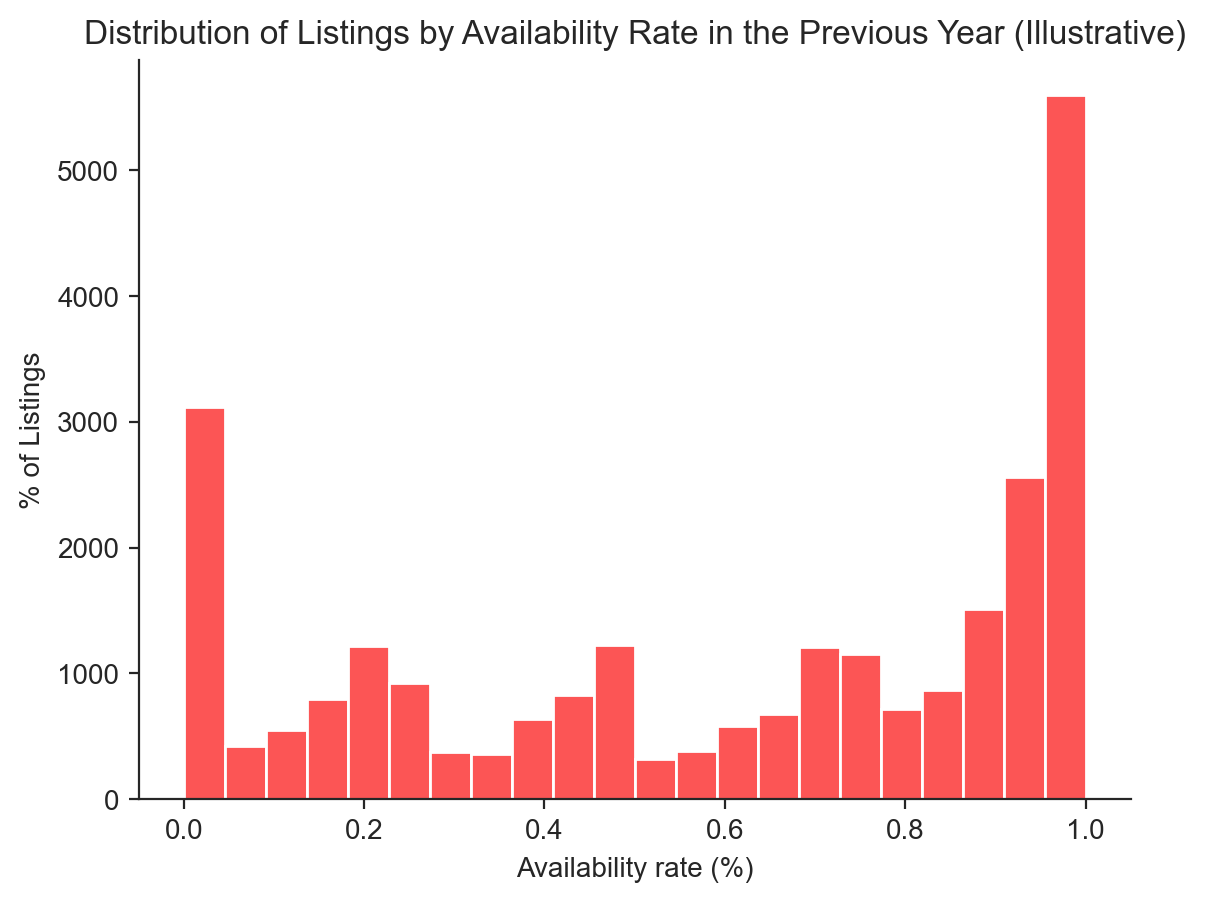

In [24]:
# We calculate the corresponding Nights Intended to be available.
listings['availability_rate'] = listings['availability_365'].map(lambda x: x/365)

# Plot the distribution
sns.histplot(listings['availability_rate'], color="#FC1C1C")
sns.despine()
plt.title("Distribution of Listings by Availability Rate in the Previous Year (Illustrative)")
plt.xlabel("Availability rate (%)")
plt.ylabel("% of Listings")
plt.show()

## Streakiness

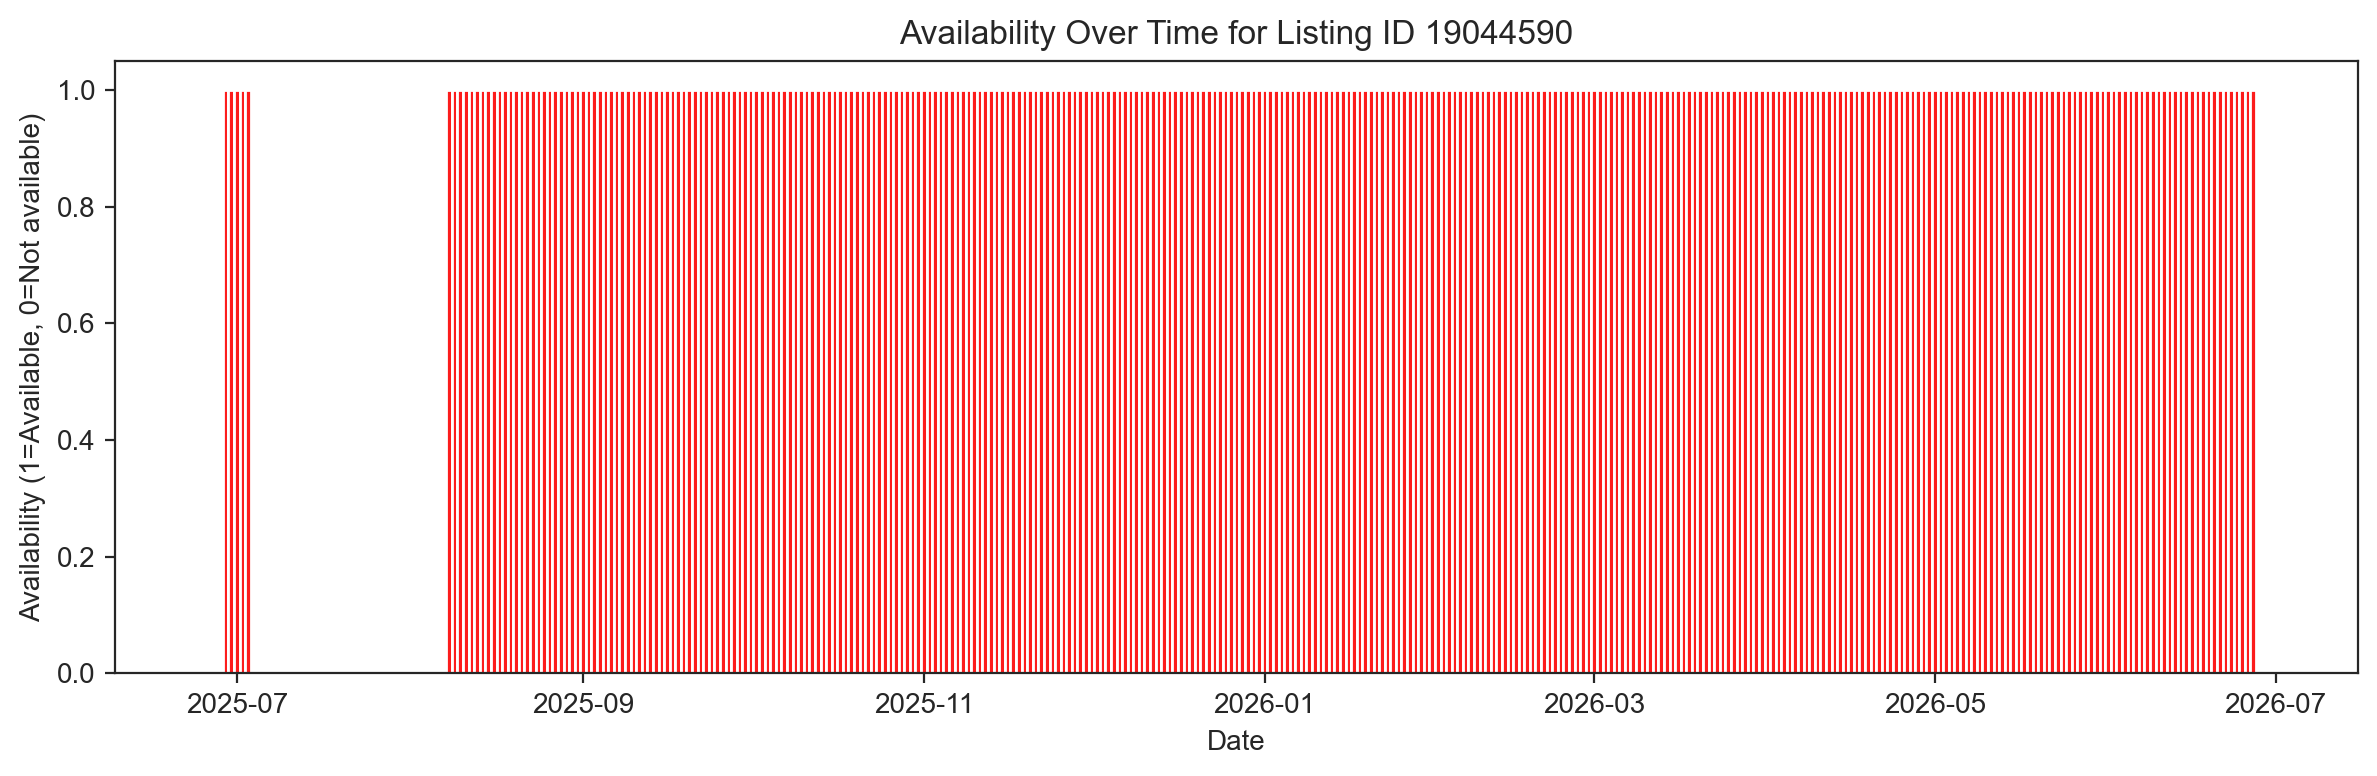

In [25]:
# get random listing on listings DataFrame
list_sample = listings.sample()
# Find the data in calendar DataFrame
listing_selected = calendar[calendar['listing_id'] == int(list_sample['id'])]
listing_selected['available'] = listing_selected['available'].map(lambda x: x == 't')

# Time series plot: availability by date for listing_selected
listing_selected['date'] = pd.to_datetime(listing_selected['date'])
plt.figure(figsize=(12,4))
#plt.plot(listing_selected['date'], listing_selected['available'].astype(int), marker='o', linestyle='-', color="#FF5A5F")
plt.bar(listing_selected['date'], listing_selected['available'].astype(int), color="#FC1C1C", width=1, align='center')
plt.ylabel('Availability (1=Available, 0=Not available)')
plt.xlabel('Date')
plt.title(f"Availability Over Time for Listing ID {listing_selected['listing_id'].iloc[0]}")
plt.tight_layout()
plt.show()

We define a streak as a consecutive sequence of availability with a minimum of 2 consecutive nights, followed by a subsequent period of at least 2 consecutive nights of unavailability.

In [26]:
# Find streaks of availability and unavailability in listing_selectec
def find_streaks(df, min_streak=2):
    """
    Finds streaks of available and unavailable periods with at least min_streak consecutive days.
    Returns a list of tuples: (start_date, end_date, available, streak_length)
    """
    streaks = []
    current = None
    streak_start = None
    streak_len = 0

    for idx, row in df.iterrows():
        avail = row['available']
        date = row['date']
        if current is None:
            current = avail
            streak_start = date
            streak_len = 1
        elif avail == current:
            streak_len += 1
        else:
            if streak_len >= min_streak:
                streaks.append((streak_start, date - pd.Timedelta(days=1), current, streak_len))
            current = avail
            streak_start = date
            streak_len = 1
    # Add last streak
    if streak_len >= min_streak:
        streaks.append((streak_start, date, current, streak_len))
    return streaks


def get_streaks(calendar_listing: pd.DataFrame) -> int:
    """
    Compute and return number streaks
    """

    # Ensure sorted by date
    listing_selected = calendar_listing.sort_values('date').reset_index(drop=True)

    # Find all streaks
    all_streaks = find_streaks(listing_selected, min_streak=2)

    # Count and return streaks
    streaks_by_listing = pd.DataFrame(all_streaks, columns=['available_start', 'available_end', 'available', 'available_length'])

    return streaks_by_listing[streaks_by_listing['available'] == 't'].shape[0]


# add new column with value of streaks
listings['streaks'] = listings['id'].map(
    lambda id : get_streaks(calendar[calendar['listing_id'] == int(id)])
)

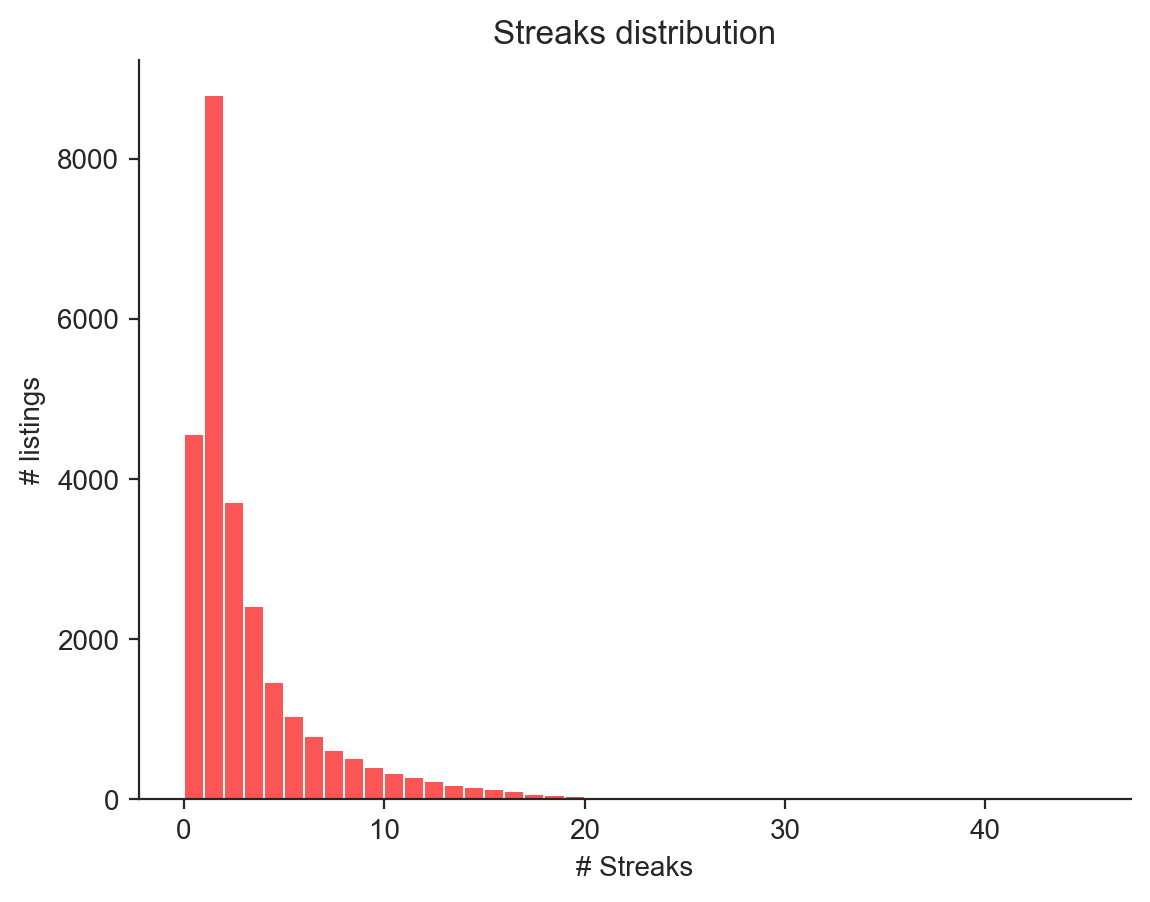

In [27]:
sns.histplot(listings['streaks'], color='#FC1C1C', binwidth=1)
sns.despine()
plt.title("Streaks distribution")
plt.xlabel("# Streaks")
plt.ylabel("# listings")
plt.show()

## Seasonality

In [28]:
def quarters_with_availability(calendar_listing: pd.DataFrame) -> int:
    """
    Returns the number of quarters (3-month periods) with at least one night available.
    """
    if calendar_listing.empty:
        return 0
    df = calendar_listing.copy()
    df['date'] = pd.to_datetime(df['date'])
    # Map 'available' to boolean if not already
    if df['available'].dtype != bool:
        df['available'] = df['available'].map(lambda x: x == 't')
    df['quarter'] = df['date'].dt.to_period('Q')
    quarters = df[df['available']].groupby('quarter').size()
    return len(quarters)

# Example: add as a feature to listings DataFrame
listings['quarters_with_availability'] = listings['id'].map(
    lambda id: quarters_with_availability(calendar[calendar['listing_id'] == int(id)])
)

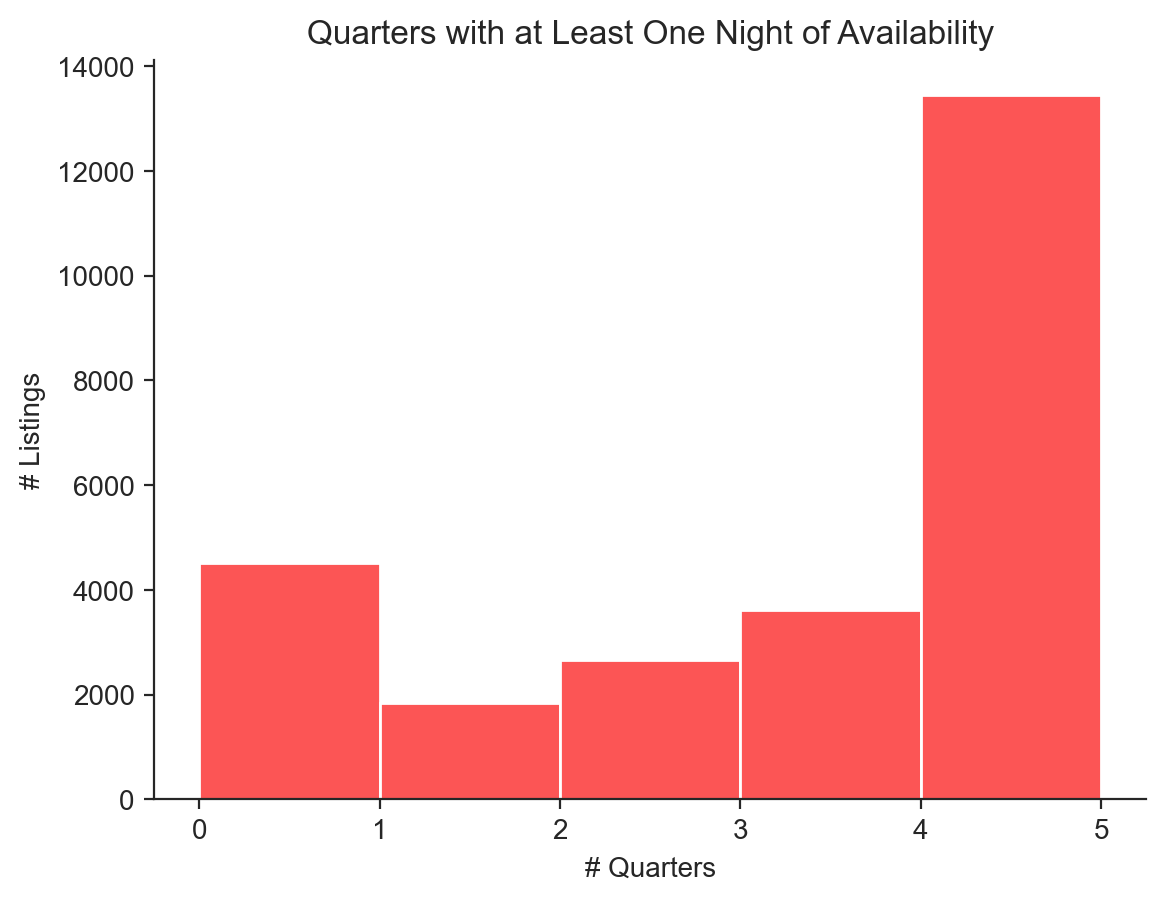

In [29]:
sns.histplot(listings['quarters_with_availability'], color='#FC1C1C', binwidth=1)
sns.despine()

plt.title("Quarters with at Least One Night of Availability")
plt.xlabel("# Quarters")
plt.ylabel("# Listings")
plt.show()

In [30]:
def max_consecutive_months_available(calendar_listing: pd.DataFrame) -> int:
    """
    Returns the maximum number of consecutive months with at least one night available.
    """
    if calendar_listing.empty:
        return 0
    df = calendar_listing.copy()
    df['date'] = pd.to_datetime(df['date'])
    # Map 'available' to boolean if not already
    if df['available'].dtype != bool:
        df['available'] = df['available'].map(lambda x: x == 't')
    # Get months with at least one available night
    months = df[df['available']].copy()
    if months.empty:
        return 0
    months['month'] = months['date'].dt.to_period('M')
    unique_months = sorted(months['month'].unique())
    # Find max consecutive months
    max_streak = streak = 1 if unique_months else 0
    for i in range(1, len(unique_months)):
        if unique_months[i-1] + 1 == unique_months[i]:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 1
    return max_streak

# Add as a feature to listings DataFrame
listings['max_consecutive_months_available'] = listings['id'].map(
    lambda id: max_consecutive_months_available(calendar[calendar['listing_id'] == int(id)])
)

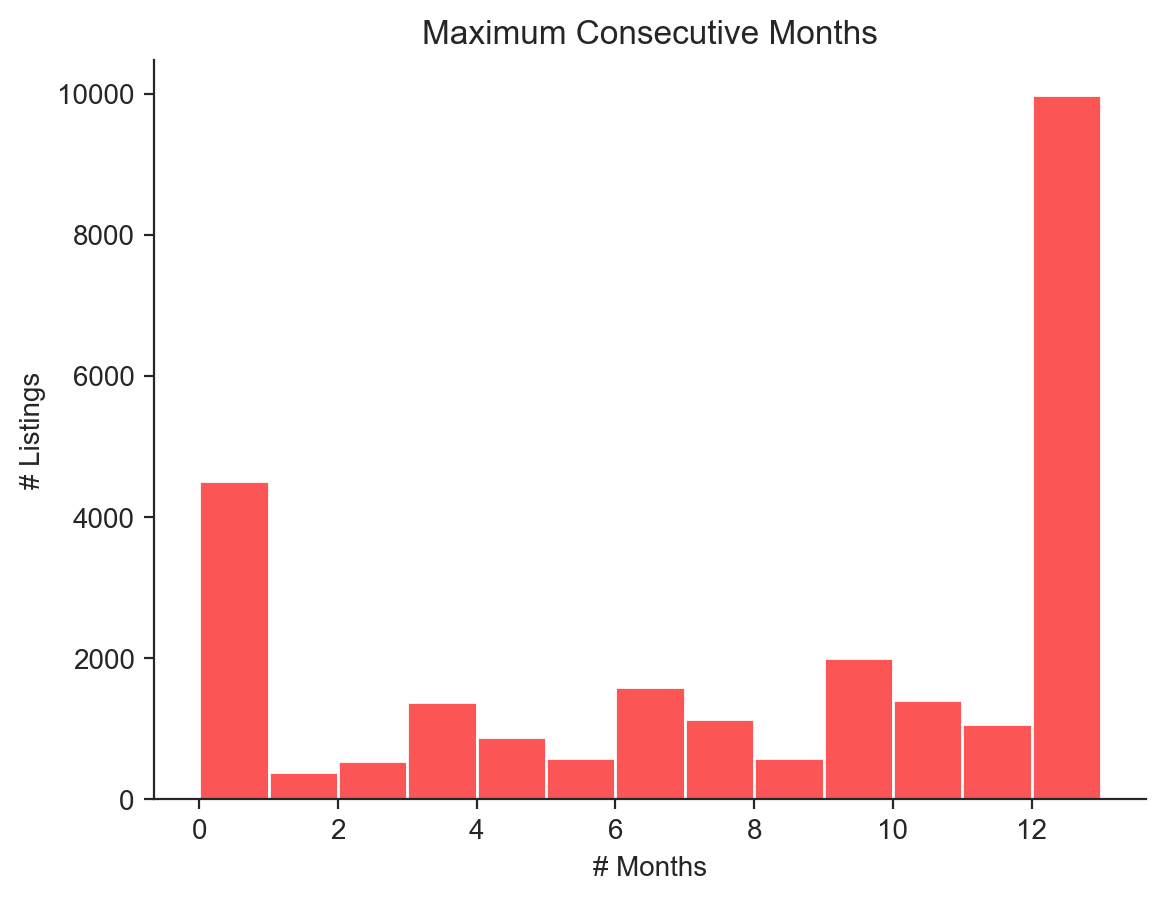

In [31]:
sns.histplot(listings['max_consecutive_months_available'], color='#FC1C1C', binwidth=1)
sns.despine()
plt.title("Maximum Consecutive Months")
plt.xlabel("# Months")
plt.ylabel("# Listings")
plt.show()

## Categorical Variables

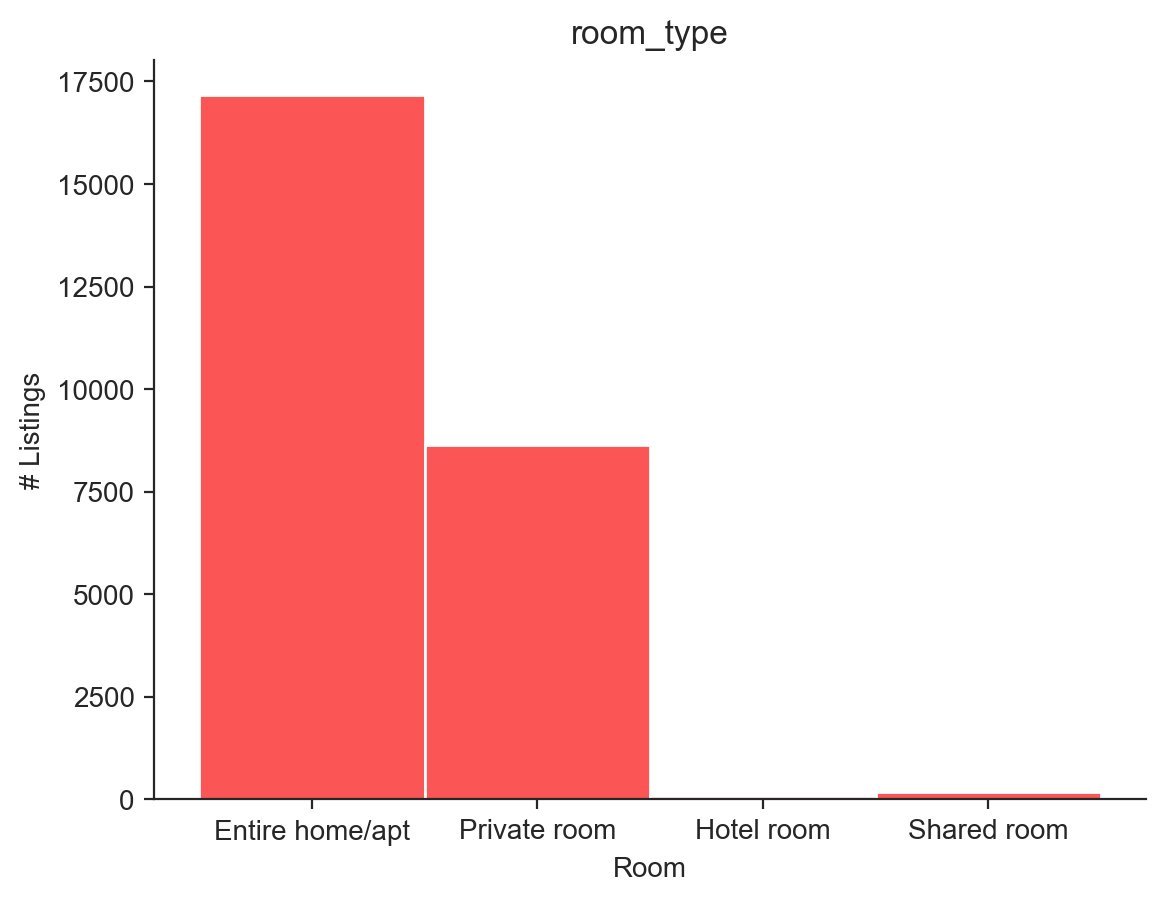

In [32]:
sns.histplot(listings['room_type'], color='#FC1C1C', binwidth=1)
sns.despine()
plt.title("room_type")
plt.xlabel("Room")
plt.ylabel("# Listings")
plt.show()

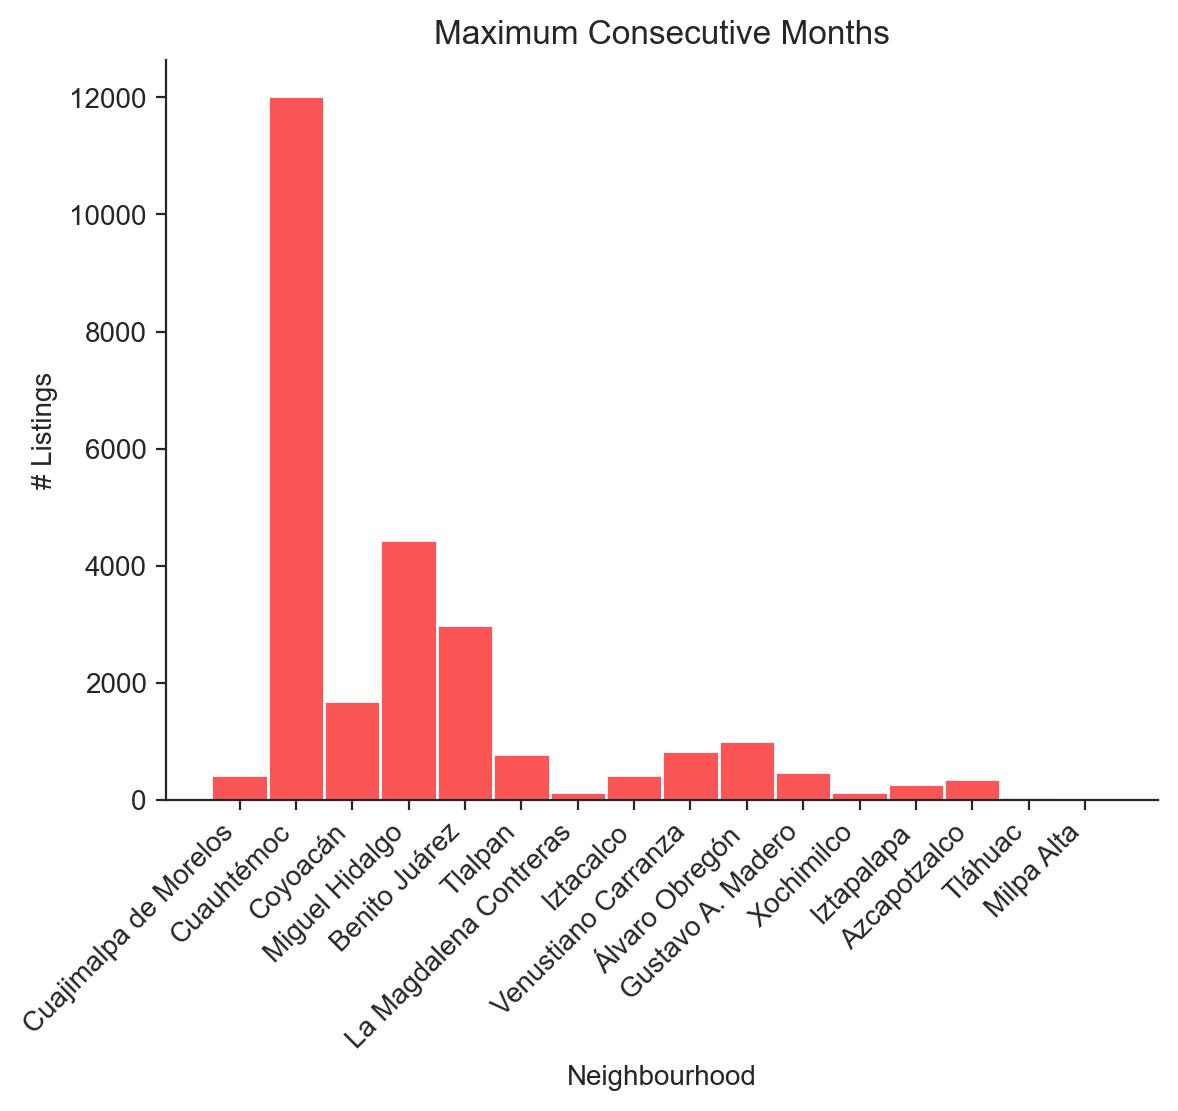

In [33]:
ax = sns.histplot(listings['neighbourhood_cleansed'], color='#FC1C1C', binwidth=1)
sns.despine()
plt.title("Maximum Consecutive Months")
plt.xlabel("Neighbourhood")
plt.ylabel("# Listings")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right') # ha='right' for right alignment
plt.show()

In [34]:
from sklearn.preprocessing import LabelEncoder

for x in listings[['room_type', 'neighbourhood_cleansed']].select_dtypes(include='object'):
    print(x)
    le = LabelEncoder()
    le.fit(listings[x])
    print(le.classes_)
    listings[x + '_le'] = le.transform(listings[x])


room_type
['Entire home/apt' 'Hotel room' 'Private room' 'Shared room']
neighbourhood_cleansed
['Azcapotzalco' 'Benito Juárez' 'Coyoacán' 'Cuajimalpa de Morelos'
 'Cuauhtémoc' 'Gustavo A. Madero' 'Iztacalco' 'Iztapalapa'
 'La Magdalena Contreras' 'Miguel Hidalgo' 'Milpa Alta' 'Tlalpan'
 'Tláhuac' 'Venustiano Carranza' 'Xochimilco' 'Álvaro Obregón']


In [35]:
# Truncate values upper the percentile 99 
p99_values = {
    'price': listings['price'].quantile(.99)
}

for col, upper_limit in p99_values.items():
    #pass
    listings[col] = listings[col].clip(upper=upper_limit)

## TAD

In [36]:
features = [
    'availability_rate', 
    'streaks', 
    'quarters_with_availability', 
    'max_consecutive_months_available', 
    'latitude', 'longitude', 
    'price',
    'room_type', 
    'neighbourhood_cleansed',
    'room_type_le', 
    'neighbourhood_cleansed_le',
    'id'  # include 'id' for reference
    ]

In [37]:
df = listings[features]

In [38]:
# Select features for clustering
features_selected = [
    'availability_rate', 
    'streaks', 
    'quarters_with_availability', 
    'max_consecutive_months_available', 
    #'latitude', 'longitude', 
    #'price',
    #'room_type_le', 
    #'neighbourhood_cleansed_le'
    ]

In [39]:
df[features_selected].describe(percentiles=[0.01, .25, .5, .75, .99])

,availability_rate,streaks,quarters_with_availability,max_consecutive_months_available
count,26067.00,26067.00,26067.00,26067.00
mean,0.60,2.90,2.94,7.76
std,0.36,3.75,1.74,4.81
min,0.00,0.00,0.00,0.00
1%,0.00,0.00,0.00,0.00
25%,0.24,1.00,2.00,3.00
50%,0.71,1.00,4.00,9.00
75%,0.94,4.00,4.00,12.00
99%,1.00,17.00,5.00,13.00
max,1.00,45.00,5.00,13.00


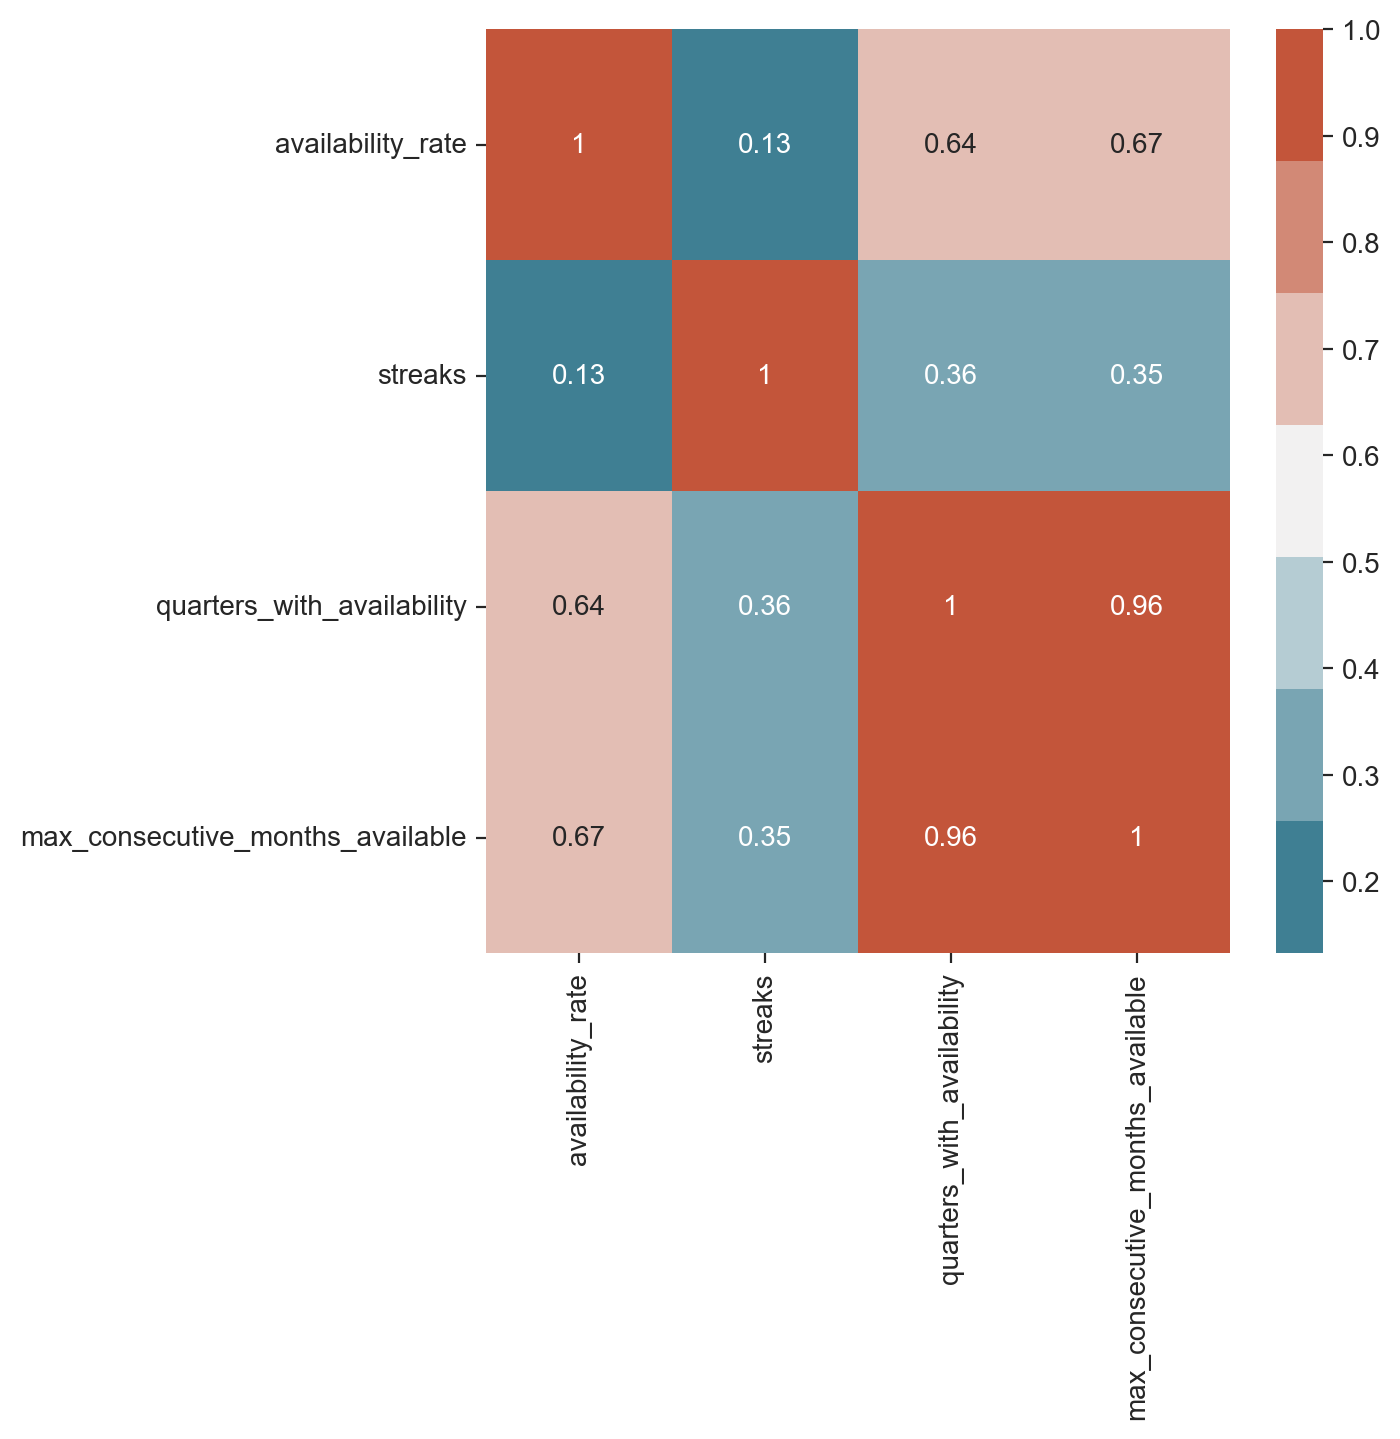

In [40]:
plt.figure(figsize=(6,6))
sns.heatmap(df[features_selected].corr(), annot=True, cmap=sns.diverging_palette(220, 20, n=7))
plt.show()

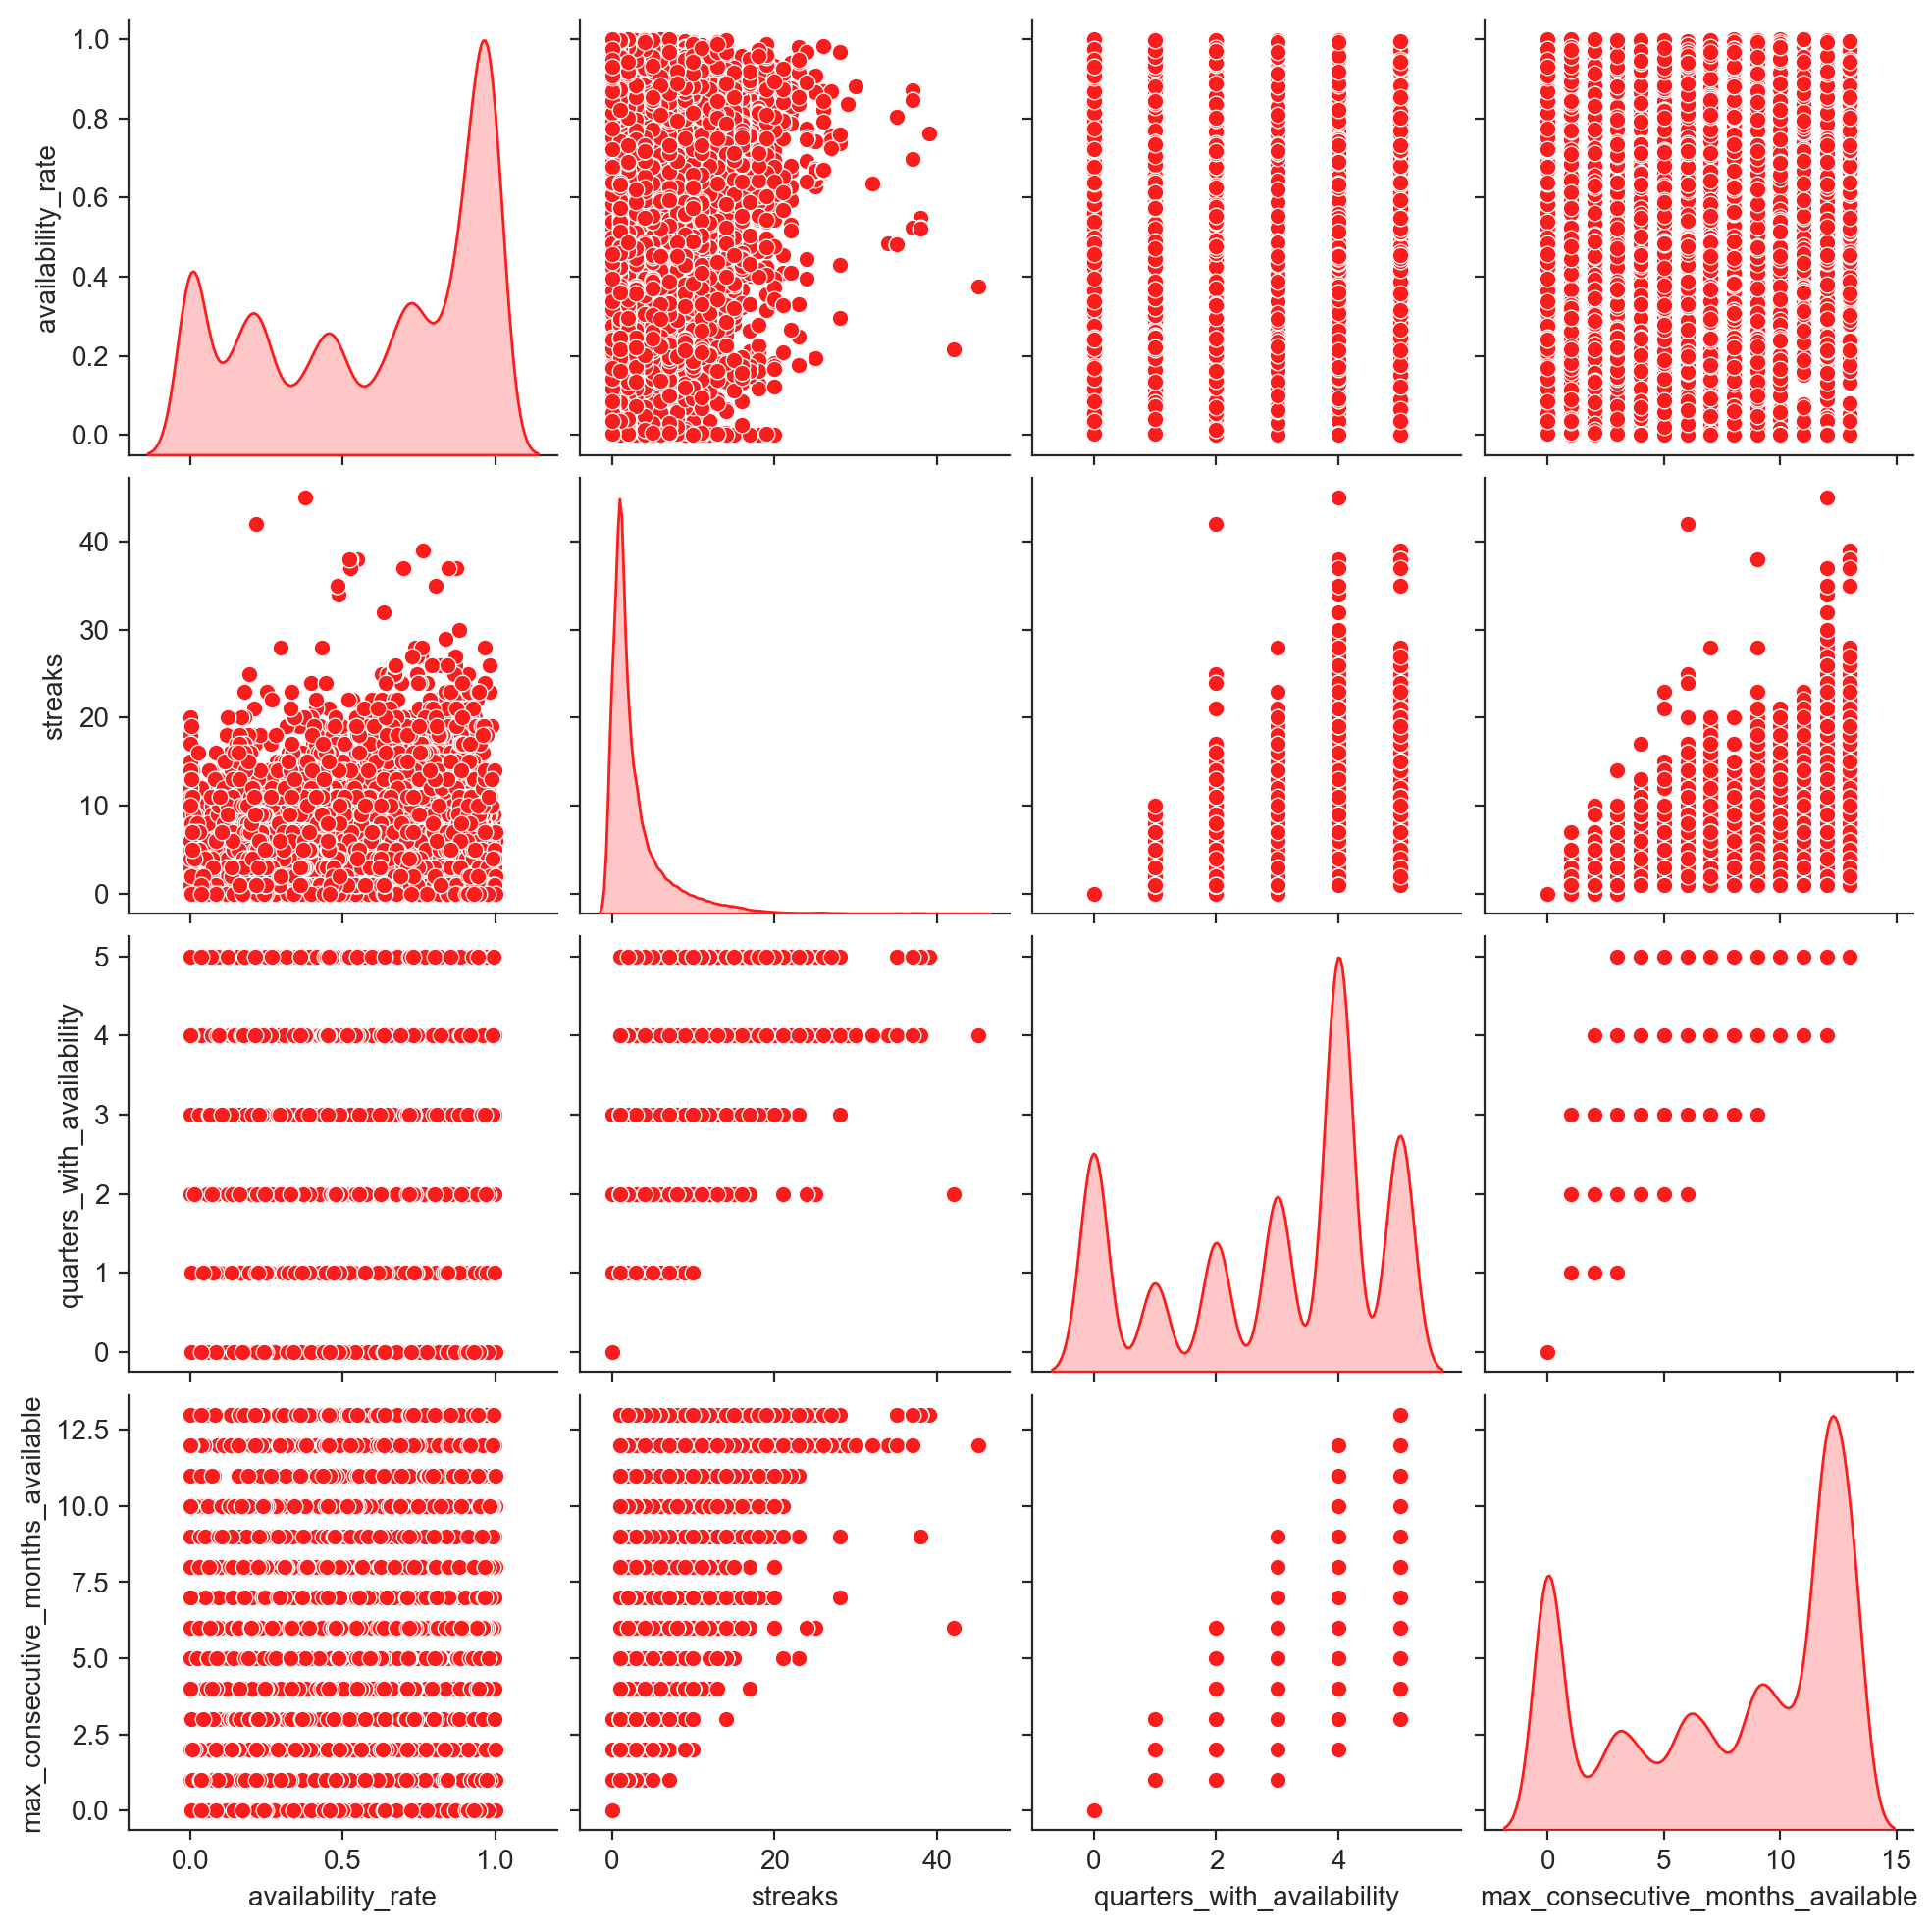

In [41]:
sns.pairplot(df[features_selected], 
             diag_kind="kde", 
             plot_kws={'color': '#FC1C1C'}, 
             diag_kws={'color': '#FC1C1C'},
             )
sns.despine()
plt.show()

# Save data

In [ ]:
import sqlite3
import joblib

# save data to database
def save_listings_to_db(df, db_path):
    conn = sqlite3.connect(db_path)
    df.to_sql('calendar_streaks', conn, if_exists='replace', index=False)
    conn.close()

# query calendar_streaks table
def load_listings(db_path):
    conn = sqlite3.connect(db_path)
    query = """SELECT * FROM calendar_streaks"""
    listings_df = pd.read_sql_query(query, conn)
    conn.close()
    return listings_df

features = [
    'availability_rate', 
    'streaks', 
    'quarters_with_availability', 
    'max_consecutive_months_available', 
    'latitude', 'longitude', 
    'price',
    'room_type', 
    'neighbourhood_cleansed',
    'room_type_le', 
    'neighbourhood_cleansed_le',
    'id'  # include 'id' for reference
    ]

save_listings_to_db(df[features], 'db/airbnb.db')

load_listings('db/airbnb.db').head()

,availability_rate,streaks,quarters_with_availability,max_consecutive_months_available,latitude,longitude,price,room_type,neighbourhood_cleansed,room_type_le,neighbourhood_cleansed_le,id
0,0.99,1,5,13,19.38,-99.27,3982.00,Entire home/apt,Cuajimalpa de Morelos,0,3,35797
1,1.00,2,4,12,19.41,-99.18,NaN,Entire home/apt,Cuauhtémoc,0,4,44616
2,0.99,1,4,12,19.44,-99.16,585.00,Entire home/apt,Cuauhtémoc,0,4,56074
3,0.84,6,4,12,19.41,-99.17,NaN,Entire home/apt,Cuauhtémoc,0,4,67703
4,0.67,5,4,4,19.35,-99.16,1015.00,Entire home/apt,Coyoacán,0,2,70644


# Modeling

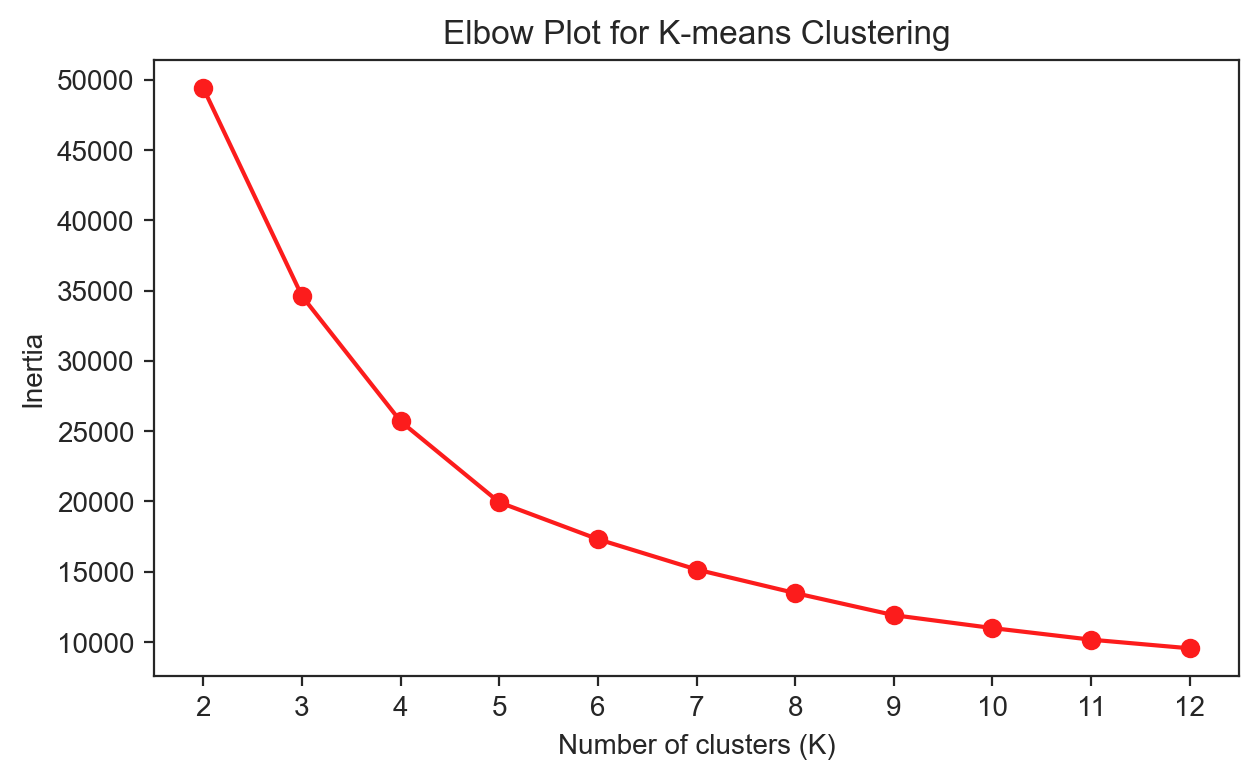

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# X = df[features_selected].fillna(0)
X = load_listings('db/airbnb.db').fillna(0)
X = X[['availability_rate', 
    'streaks', 
    'quarters_with_availability', 
    'max_consecutive_months_available']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# save scaler
joblib.dump(scaler, 'models/scaler_calendar_streaks.pkl')

# Elbow plot to determine optimal K
inertia = []
K_range = range(2, 13)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o', color='#FC1C1C')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for K-means Clustering')
plt.xticks(K_range)
plt.show()

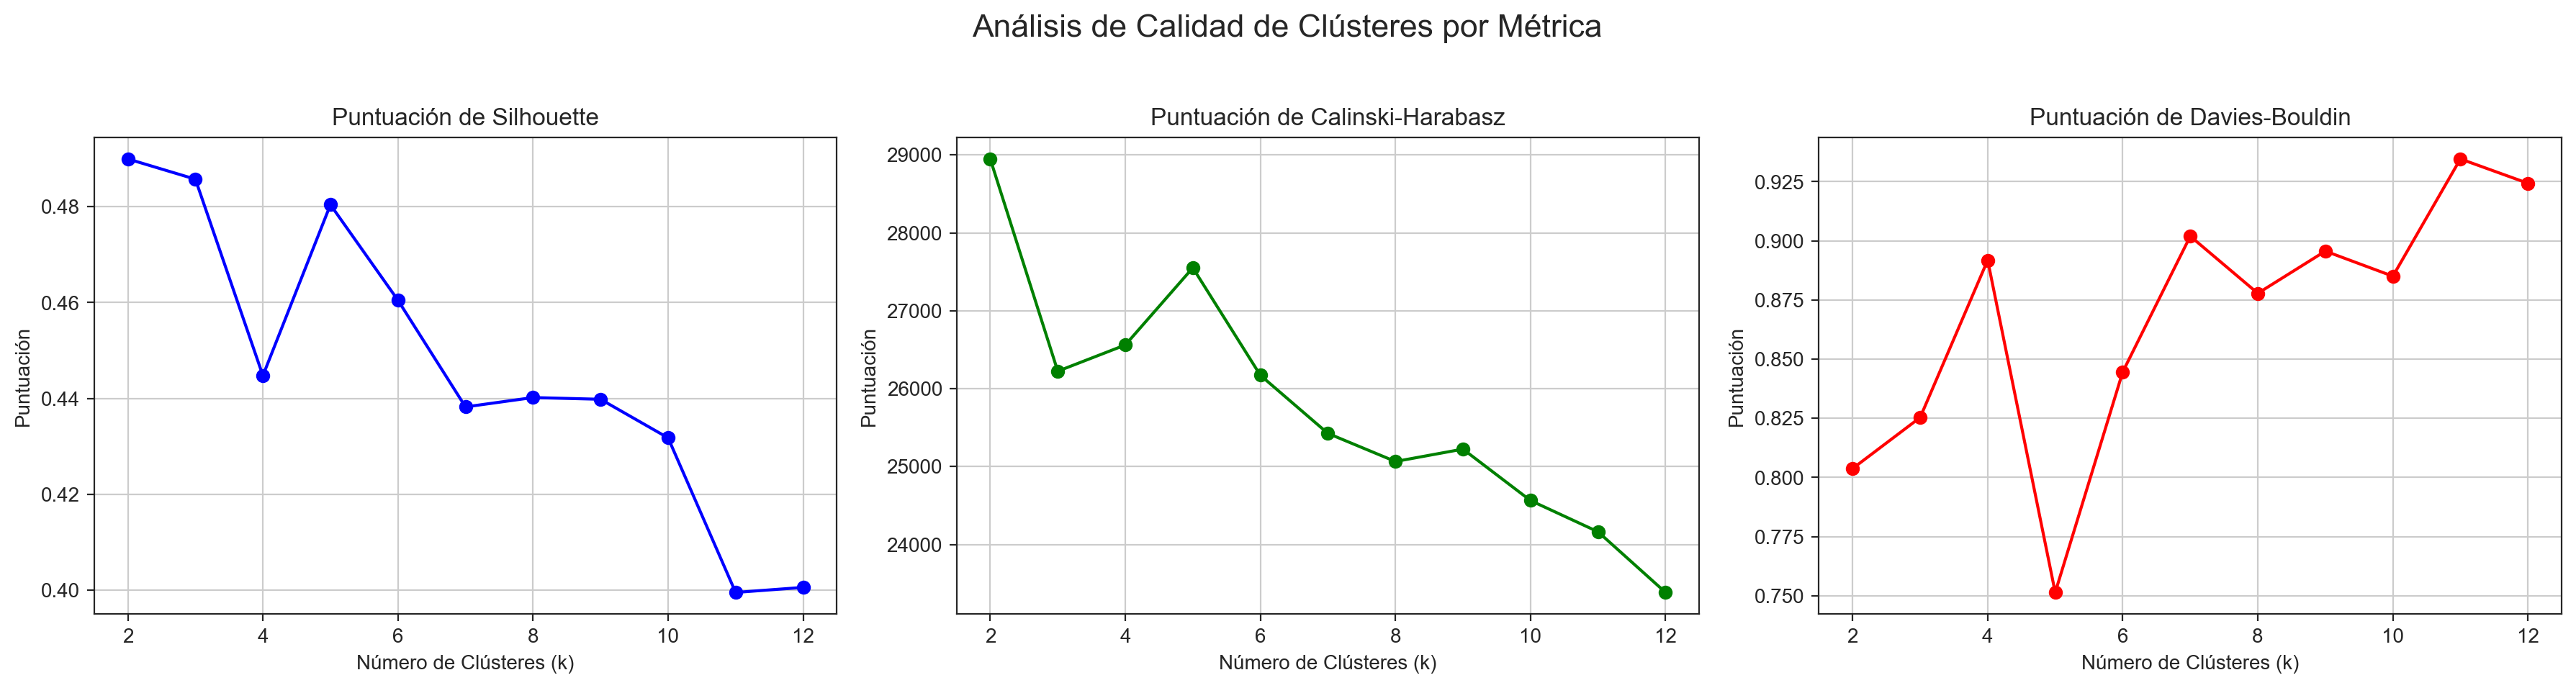

In [44]:
from sklearn.metrics import pairwise_distances, jaccard_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score

distortions = []; silhouette_scores = []
davies_bouldin_scores = []; calinski_harabasz_scores = []
range_n_clusters = range(2, 13)  # Ajustamos para explorar desde 1 hasta 7 clusters

for n_clusters in range_n_clusters:
   km = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=333)
   cluster_labels = km.fit_predict(X_scaled); distortions.append(km.inertia_)
   silhouette_ = silhouette_score(X_scaled, cluster_labels); silhouette_scores.append(silhouette_)
   davies_bouldin_ = davies_bouldin_score(X_scaled, cluster_labels); davies_bouldin_scores.append(davies_bouldin_)
   calinski_harabasz_ = calinski_harabasz_score(X_scaled, cluster_labels); calinski_harabasz_scores.append(calinski_harabasz_)

# Graficar las 3 métricas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Calidad de Clústeres por Métrica', fontsize=16)

# Silhouette Score
ax1.plot(range_n_clusters, silhouette_scores, marker='o', color='b')
ax1.set_title('Puntuación de Silhouette', fontsize=12)
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Puntuación')
ax1.grid(True)

#Calinski Harabasz
ax2.plot(range_n_clusters, calinski_harabasz_scores, marker='o', color='g')
ax2.set_title('Puntuación de Calinski-Harabasz', fontsize=12)
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Puntuación')
ax2.grid(True)

#Davies Bouldin
ax3.plot(range_n_clusters, davies_bouldin_scores, marker='o', color='r')
ax3.set_title('Puntuación de Davies-Bouldin', fontsize=12)
ax3.set_xlabel('Número de Clústeres (k)')
ax3.set_ylabel('Puntuación')
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Train and selected model with n clusters

In [ ]:
# Number of clusters to use
n_clusters = 8

# load data
X = load_listings('db/airbnb.db').fillna(0)
X = X[['availability_rate', 
    'streaks', 
    'quarters_with_availability', 
    'max_consecutive_months_available']]

# load scaler
scaler = joblib.load('models/scaler_calendar_streaks.pkl')
X_scaled = scaler.transform(X)

# Train KMeans with 5 clusters and add label to the data
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# save the model
joblib.dump(kmeans, 'models/kmeans_calendar_streaks.pkl')

# predict clusters and add to df
X["cluster_label"] = kmeans.predict(X_scaled)

In [86]:
X['cluster_label'].value_counts()

cluster_label
4    8758
0    4394
1    3255
5    3189
2    2384
6    1846
3    1246
7     995
Name: count, dtype: int64

In [88]:
X[features_selected+['cluster_label']].groupby(['cluster_label']).describe()

availability_rate                                    streaks  \
                          count mean  std  min  25%  50%  75%  max   count   
cluster_label                                                                
0                       4394.00 0.48 0.21 0.00 0.34 0.47 0.64 1.00 4394.00   
1                       3255.00 0.20 0.12 0.00 0.12 0.19 0.24 0.68 3255.00   
2                       2384.00 0.85 0.12 0.29 0.79 0.88 0.93 1.00 2384.00   
3                       1246.00 0.37 0.20 0.00 0.21 0.38 0.49 0.94 1246.00   
4                       8758.00 0.91 0.11 0.44 0.89 0.96 0.99 1.00 8758.00   
5                       3189.00 0.05 0.10 0.00 0.00 0.00 0.02 0.44 3189.00   
6                       1846.00 0.83 0.17 0.44 0.71 0.90 0.98 1.00 1846.00   
7                        995.00 0.72 0.20 0.00 0.62 0.78 0.86 1.00  995.00   

                                                        \
               mean  std   min   25%   50%   75%   max   
cluster_label                                            
0              2.06 1.23  1.00  1.00  2.00  3.00  5.00   
1              2.00 1.38  0.00  1.00  1.00  3.00  8.00   
2              7.21 1.90  4.00  6.00  7.00  9.00 11.00   
3              8.39 2.30  5.00  6.00  8.00 10.00 16.00   
4              1.80 1.00  1.00  1.00  1.00  2.00  4.00   
5              0.08 0.29  0.00  0.00  0.00  0.00  2.00   
6              0.19 0.61  0.00  0.00  0.00  0.00  7.00   
7             16.02 4.45 12.00 13.00 15.00 17.00 45.00   

              quarters_with_availability                                     \
                                   count mean  std  min  25%  50%  75%  max   
cluster_label                                                                 
0                                4394.00 3.17 0.69 2.00 3.00 3.00 4.00 5.00   
1                                3255.00 1.64 0.61 1.00 1.00 2.00 2.00 4.00   
2                                2384.00 4.35 0.52 3.00 4.00 4.00 5.00 5.00   
3                                1246.00 3.06 0.78 1.00 3.00 3.00 4.00 5.00   
4                                8758.00 4.38 0.52 3.00 4.00 4.00 5.00 5.00   
5                                3189.00 0.09 0.29 0.00 0.00 0.00 0.00 1.00   
6                                1846.00 0.19 0.53 0.00 0.00 0.00 0.00 3.00   
7                                 995.00 4.22 0.66 2.00 4.00 4.00 5.00 5.00   

              max_consecutive_months_available                              \
                                         count  mean  std  min   25%   50%   
cluster_label                                                                
0                                      4394.00  8.08 1.92 2.00  7.00  9.00   
1                                      3255.00  3.64 1.37 1.00  3.00  3.00   
2                                      2384.00 11.81 1.44 3.00 12.00 12.00   
3                                      1246.00  7.66 2.23 2.00  6.00  7.00   
4                                      8758.00 11.94 1.27 4.00 12.00 12.00   
5                                      3189.00  0.11 0.39 0.00  0.00  0.00   
6                                      1846.00  0.38 1.12 0.00  0.00  0.00   
7                                       995.00 11.52 1.78 4.00 11.00 12.00   

                           
                75%   max  
cluster_label              
0              9.00 13.00  
1              4.00  8.00  
2             13.00 13.00  
3              9.00 13.00  
4             13.00 13.00  
5              0.00  2.00  
6              0.00  6.00  
7             13.00 13.00

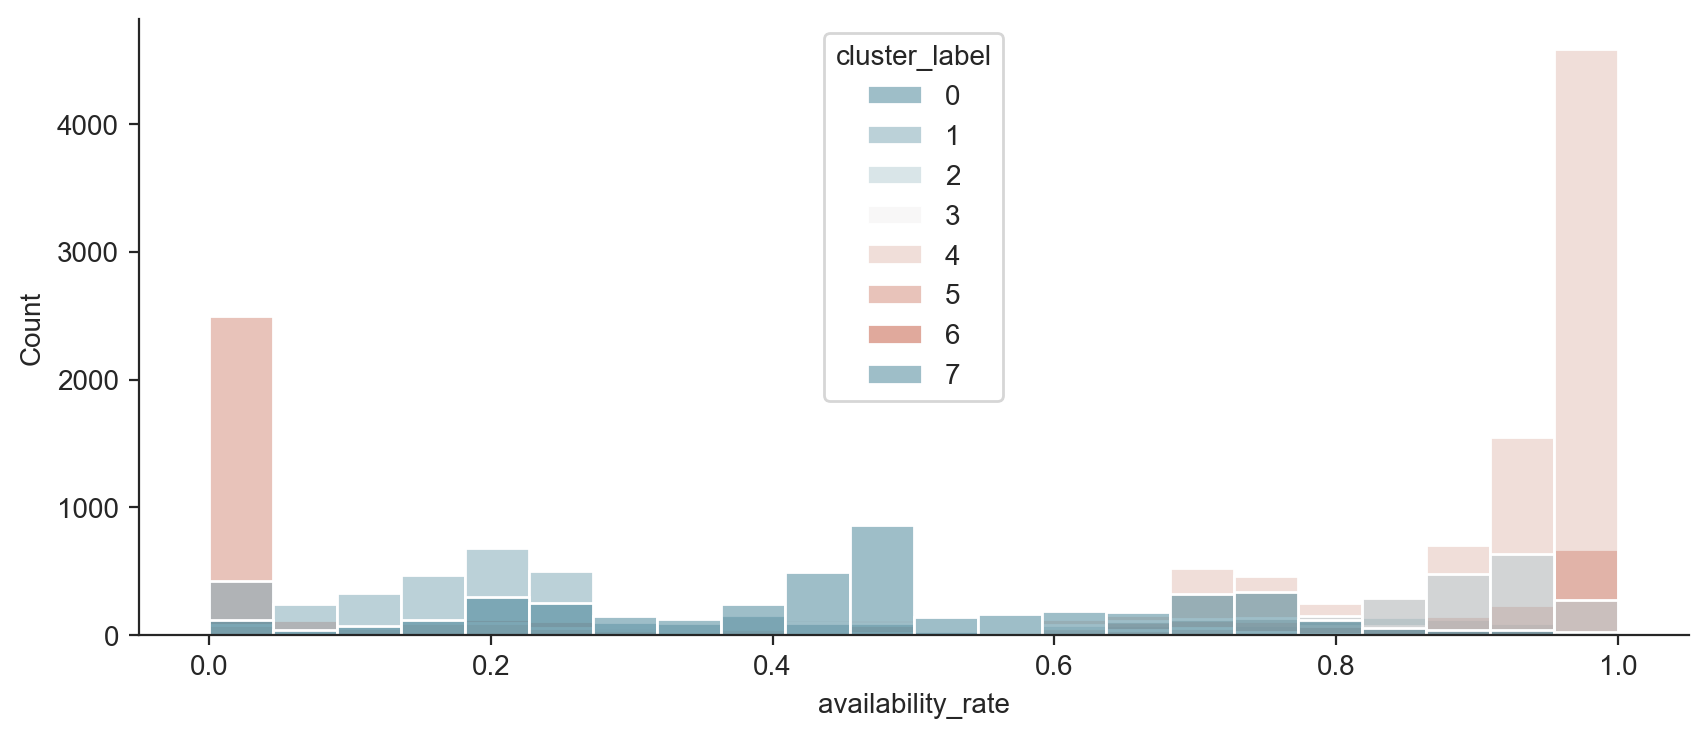

In [89]:
plt.figure(figsize=(10, 4))
sns.histplot(data=X, x="availability_rate", hue="cluster_label", palette=sns.diverging_palette(220, 20, n=7))
sns.despine()
plt.show()

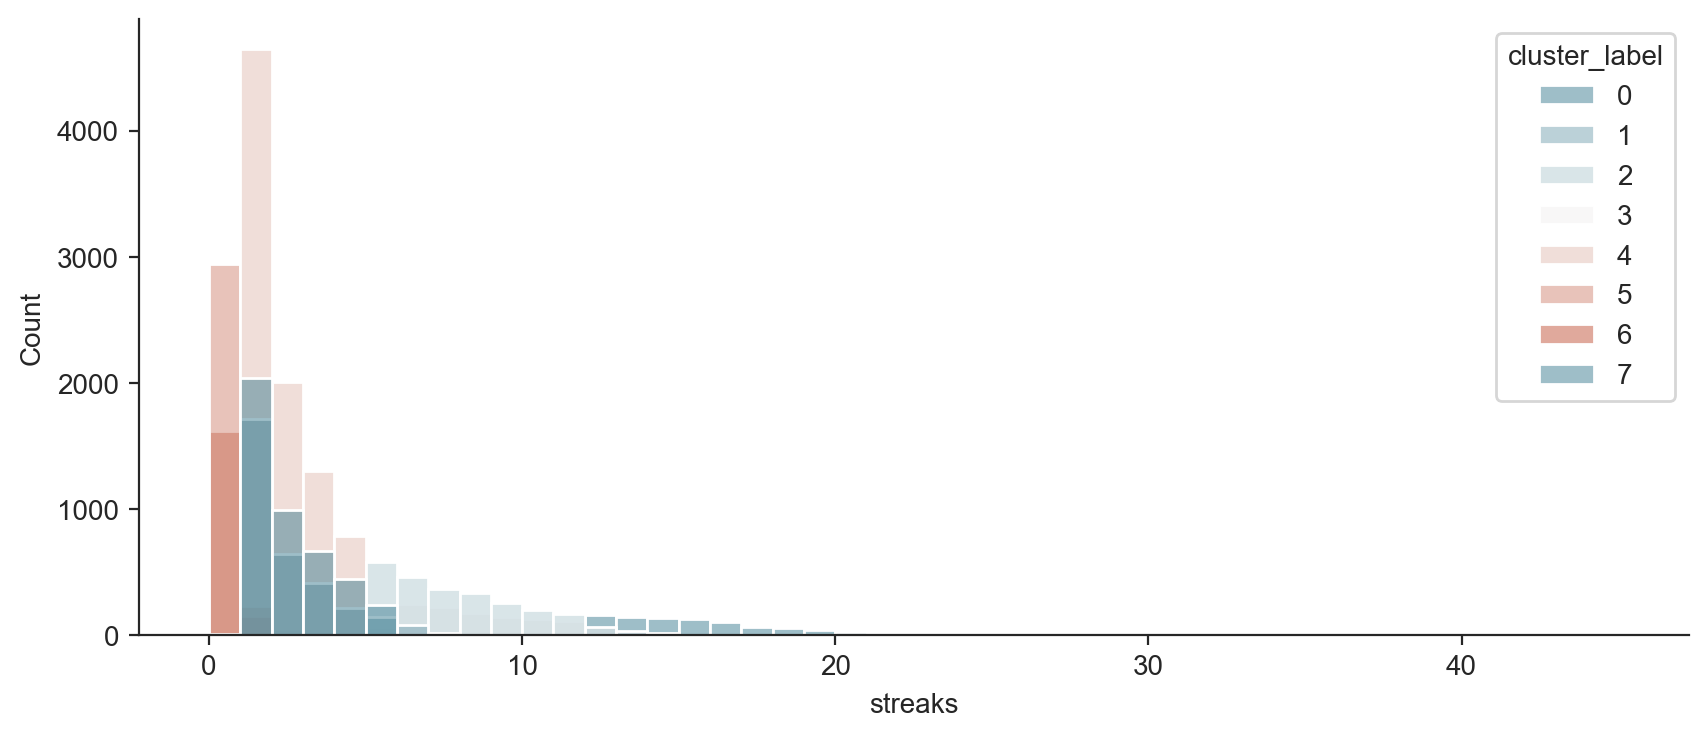

In [90]:
plt.figure(figsize=(10, 4))
sns.histplot(data=X, x="streaks", hue="cluster_label", binwidth=1, palette=sns.diverging_palette(220, 20, n=7))
sns.despine()
plt.show()

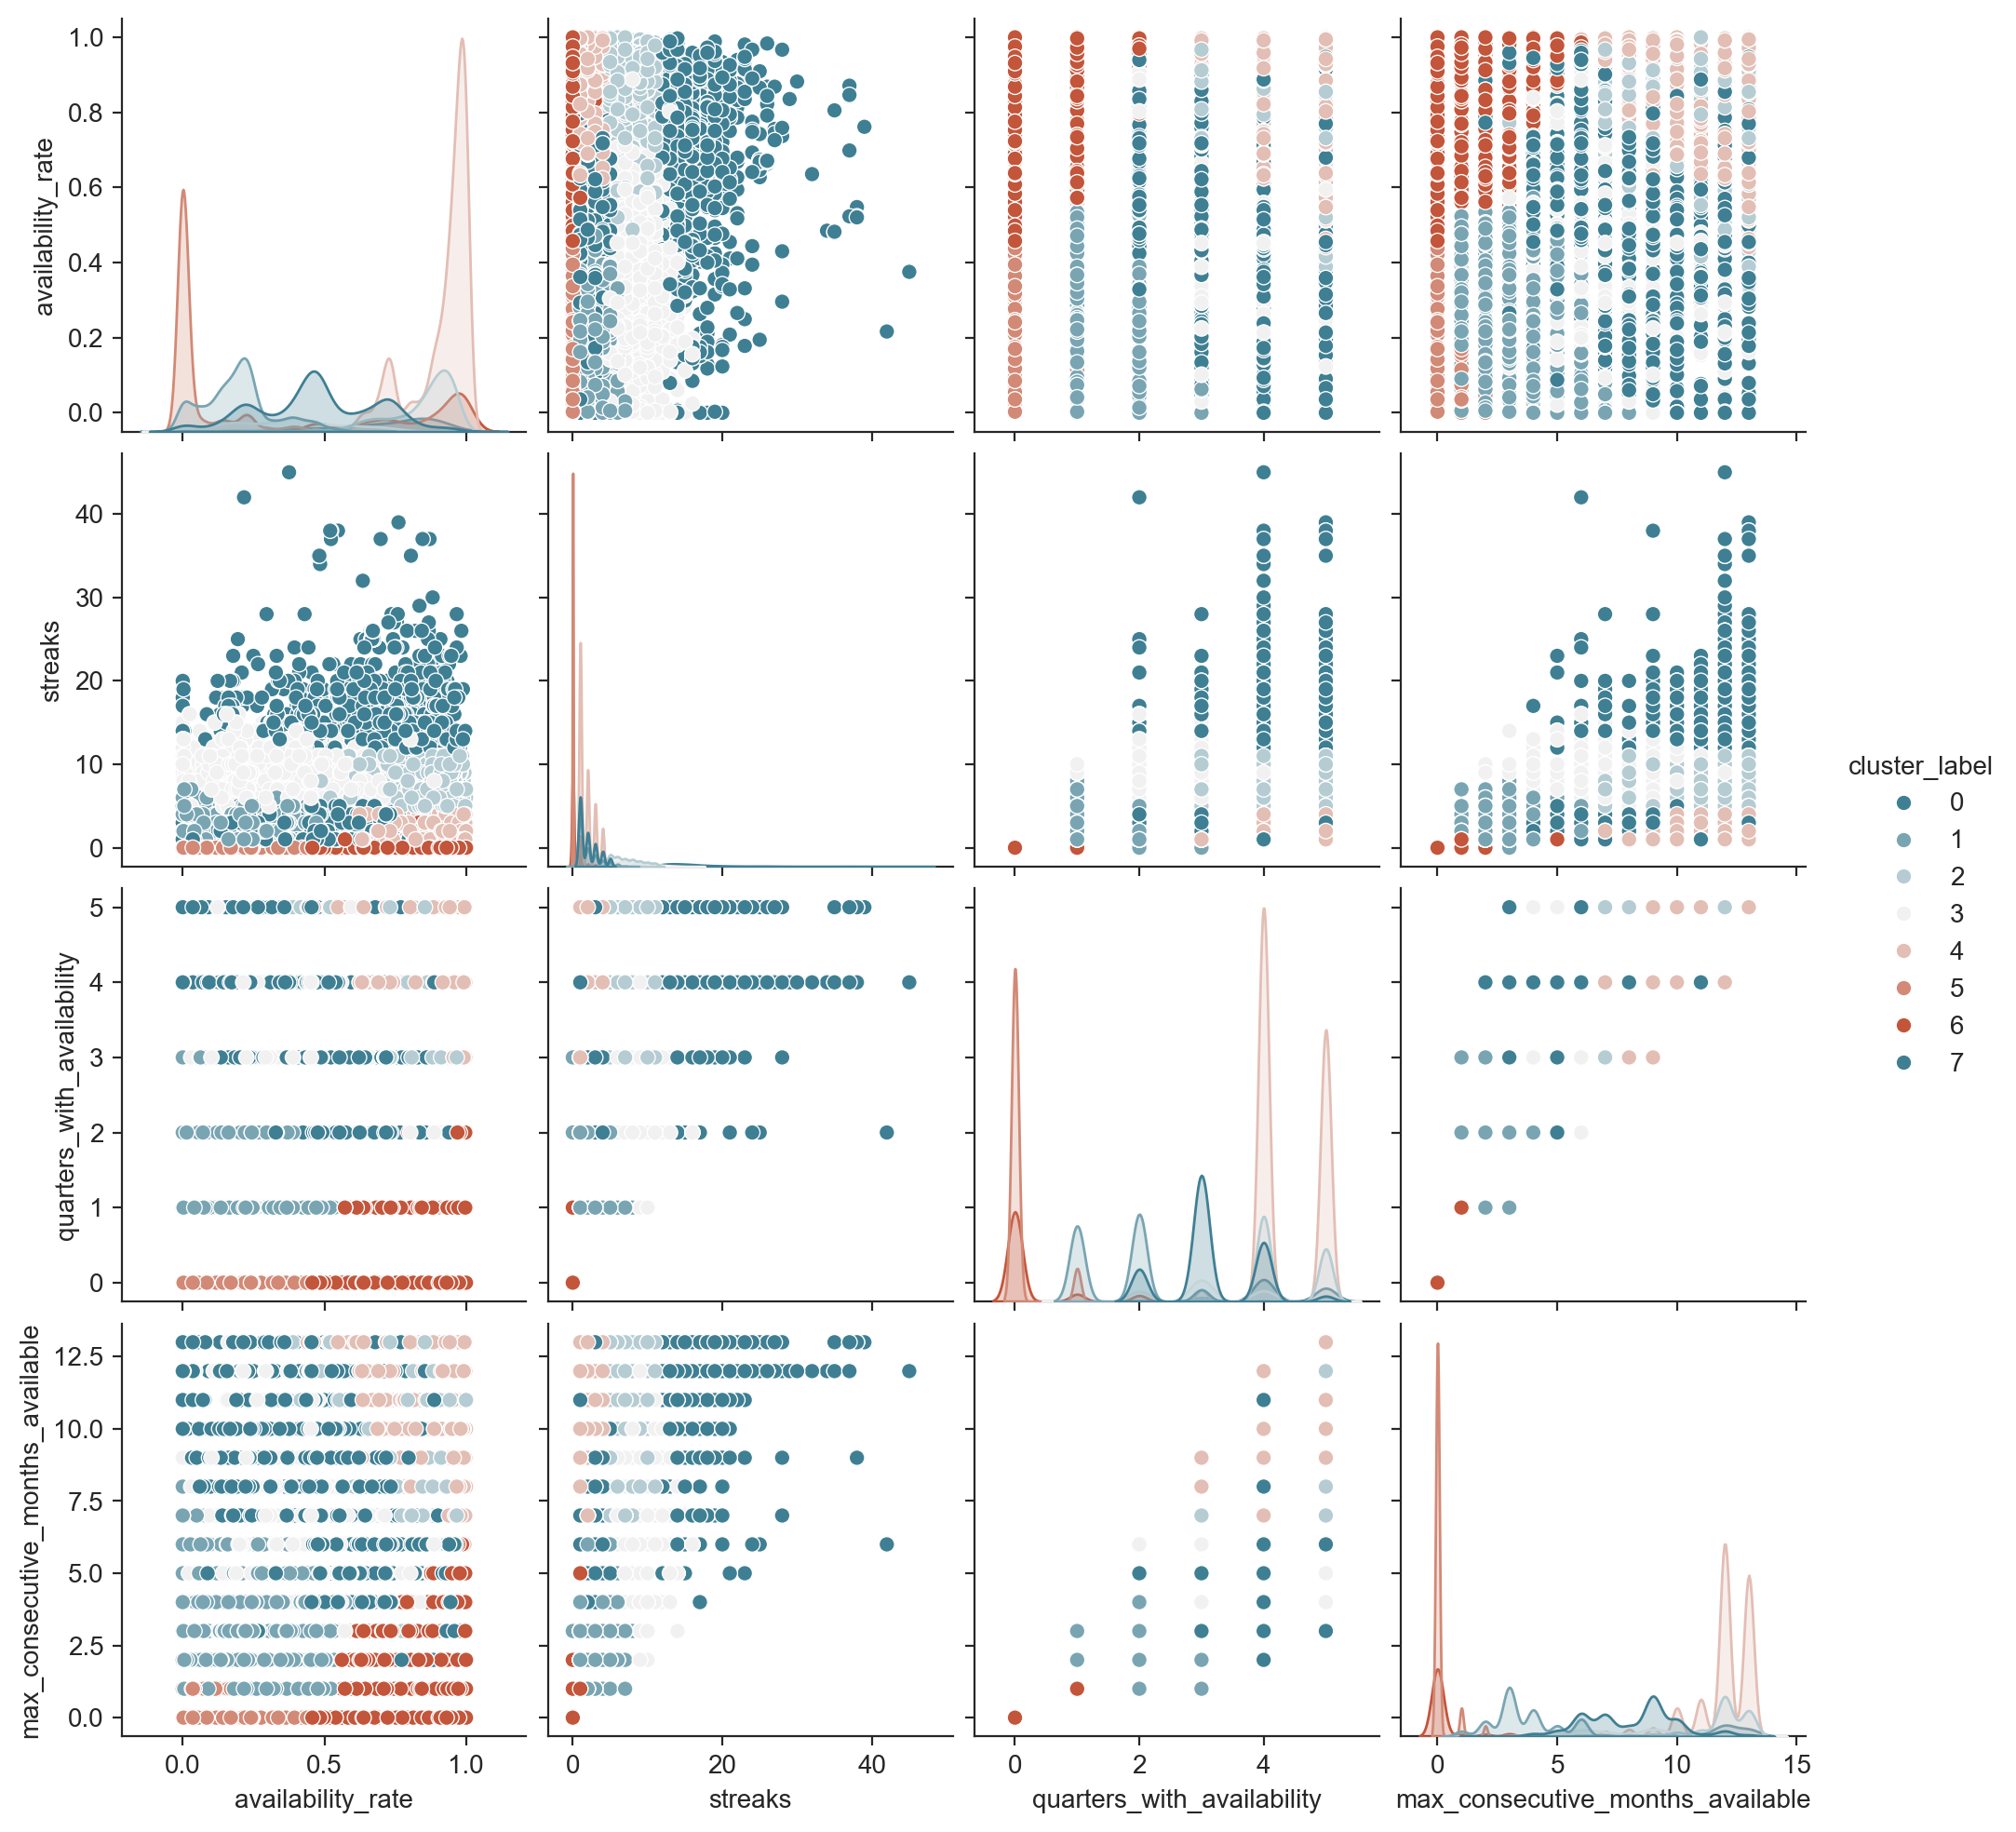

In [91]:
sns.pairplot(X[features_selected + ['cluster_label']], 
             diag_kind='kde', 
             hue='cluster_label', 
             palette=sns.diverging_palette(220, 20, n=7))
sns.despine()
plt.show()

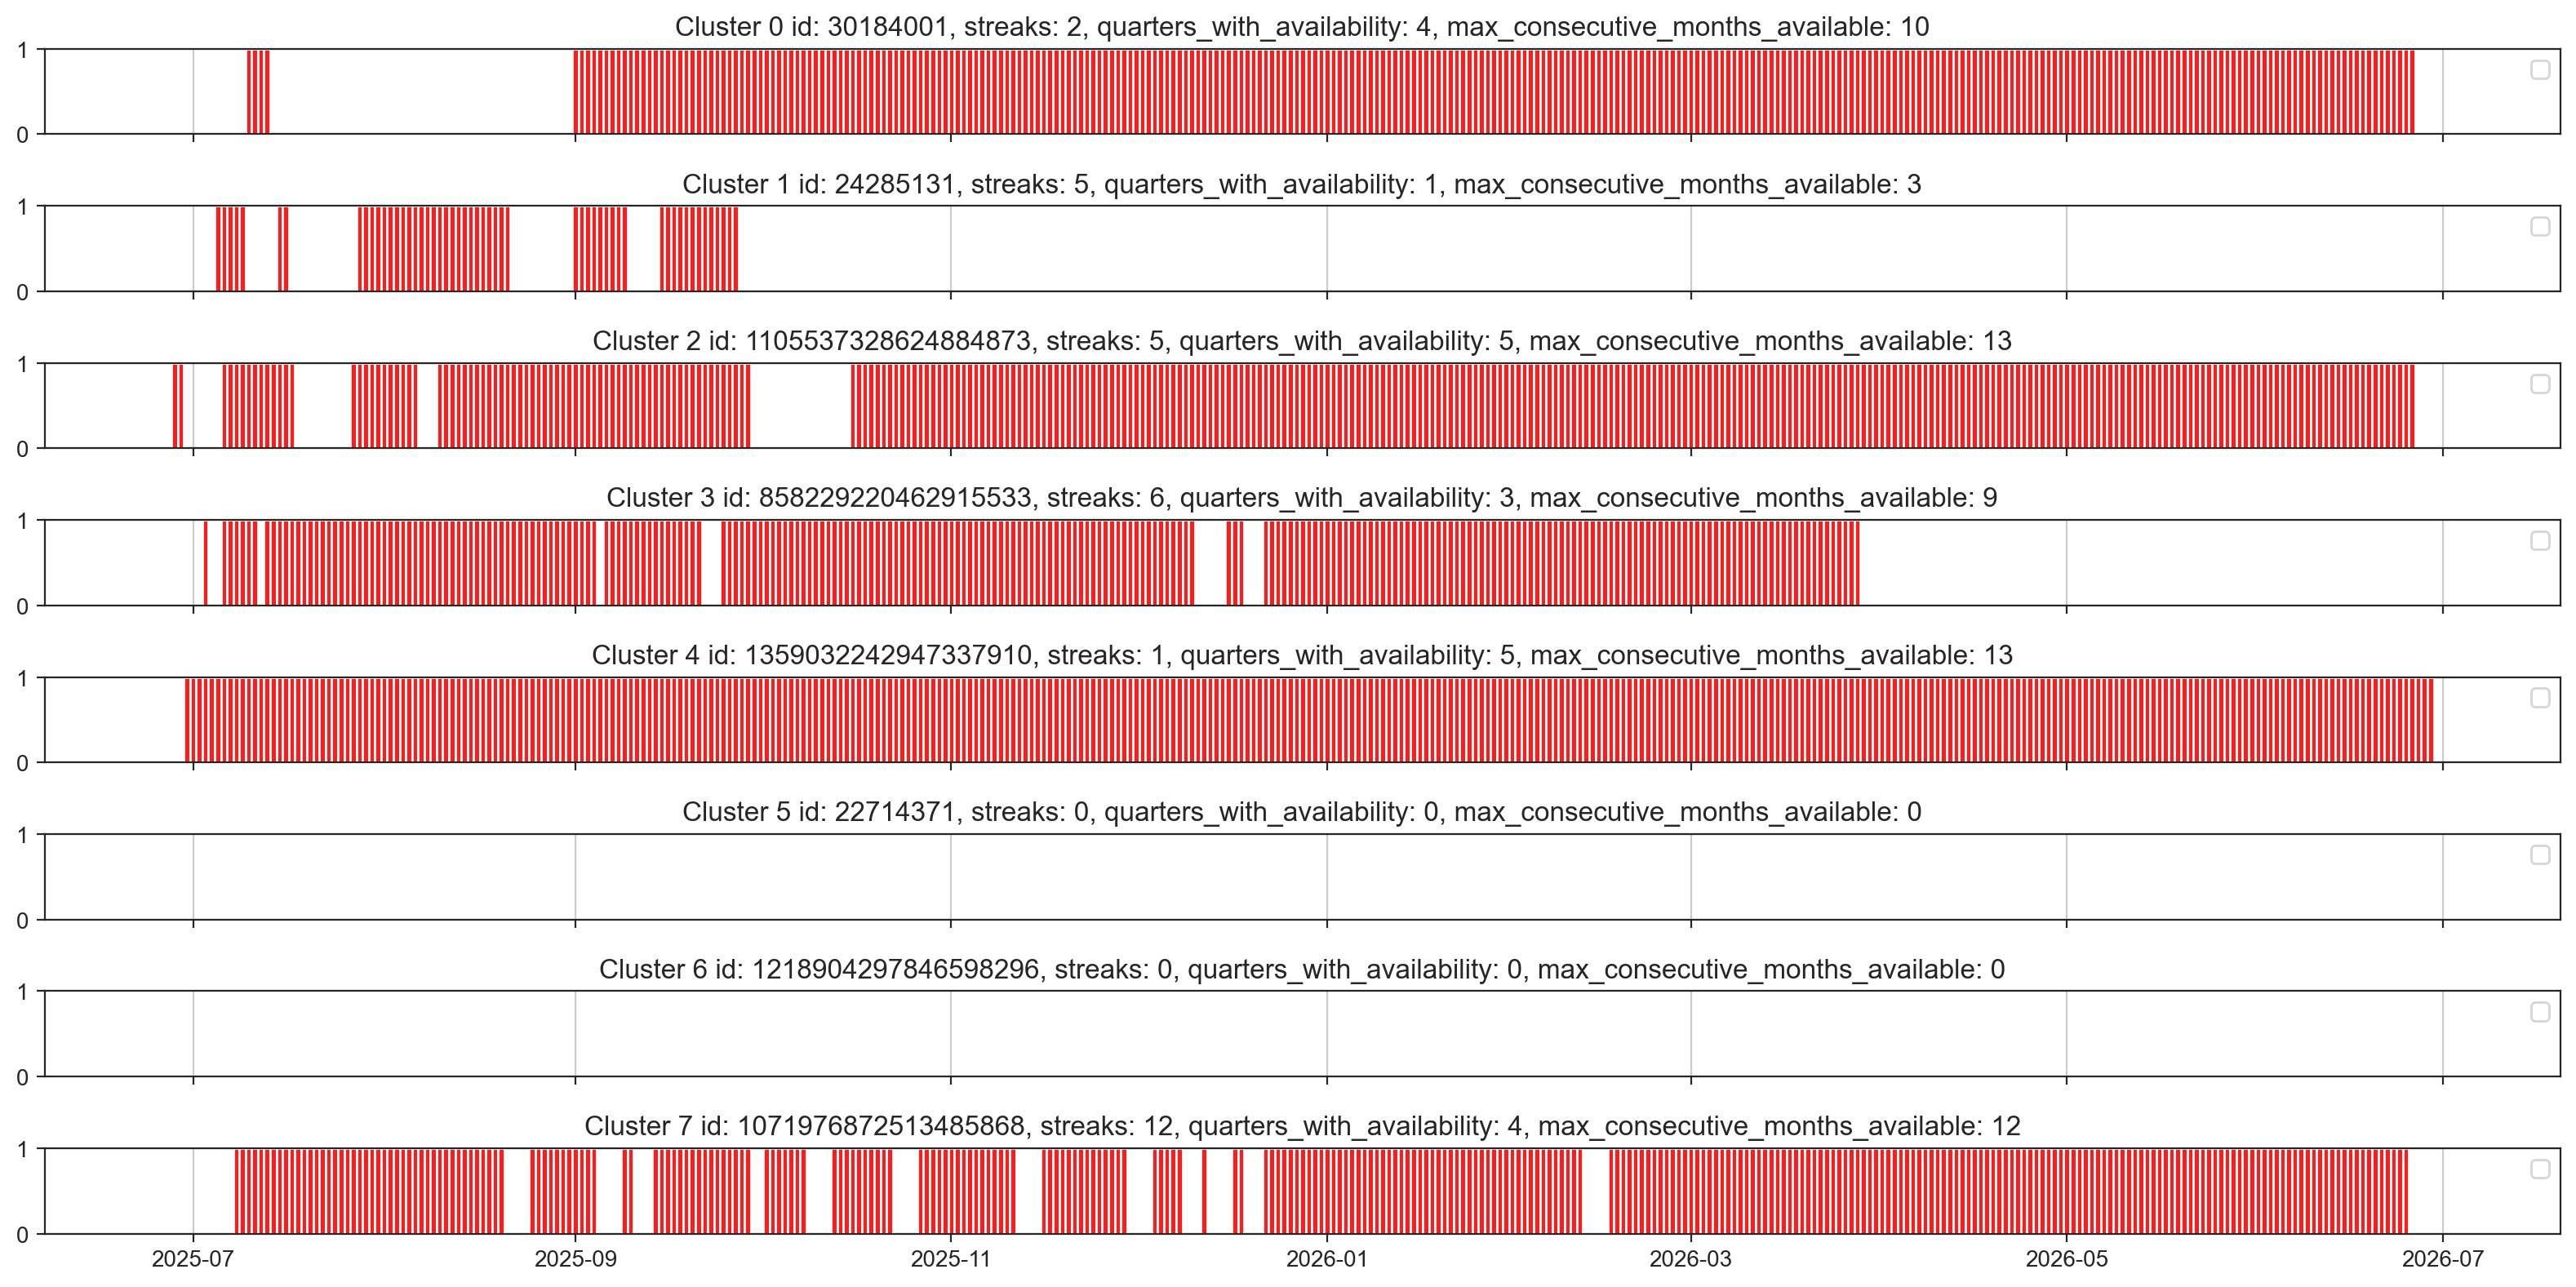

In [95]:
# Get the id of one listing 
X['id'] = listings['id']

# select one row by cluster label and grap the time series of availability
df_sample = X.groupby('cluster_label').apply(lambda x: x.sample(1)).reset_index(drop=True)

fig, axes = plt.subplots(n_clusters, 1, figsize=(16, 8), sharex=True)

for i in range(n_clusters):
    # get id by cluster
    sample_streak = df_sample[df_sample['cluster_label'] == i]['streaks']
    sample_Q_w = df_sample[df_sample['cluster_label'] == i]['quarters_with_availability']
    sample_max_months = df_sample[df_sample['cluster_label'] == i]['max_consecutive_months_available']
    
    id_calendar = df_sample[df_sample['cluster_label'] == i]['id']
    aux_calendar = calendar[calendar['listing_id'] == int(id_calendar)]
    aux_calendar['available'] = aux_calendar['available'].map(lambda x: x == 't')

    # kind time serie
    # axes[i].plot(aux_calendar['date'], aux_calendar['available'].astype(int), marker='o', linestyle='-', color="#FF5A5F")

    # 'Availability (1=Available, 0=Not available)'
    axes[i].bar(aux_calendar['date'], aux_calendar['available'].astype(int), color="#FC1C1C", width=1.0, align='center')
    axes[i].set_title(f'Cluster {i} id: {int(id_calendar)}, streaks: {int(sample_streak)}, quarters_with_availability: {int(sample_Q_w)}, max_consecutive_months_available: {int(sample_max_months)}')
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_ylim([0, 1])

plt.tight_layout()  # Ajusta el espaciado entre subgráficos
plt.show()

Con ayuda de las métricas se realizó la descripción del clúster, el nombre y la asignación de la etiqueta. La tabla de descripciones y etiquetas que se determinaron para el conjunto de datos analizados.


| Descripción del cluster | Nombre | Cluster | 
|---------------|---------------|-------------|
|100% de disponibilidad durante el transcurso del año | Siempre Disponible | 4 |
|Raros bloques de indisponibilidad durante el transcurso del año | Casi Disponible | 3 |
|Larga disponibilidad concentrada en bloques, generalmente de 2 o 3 estaciones | Estacion Larga | 0 |
|Corta disponibilidad concentrada en bloques, abarcando una sola estacion | Estacion Corta | 1 |
|Periodos de disponibilidad no tan frecuentes, con brechas de indisponibilidad | Tiempo Parcial | 2 |
|Bloques de disponibilidad intermitentes a traves del año | Esporadico | 7 |
|Raros y cortos periodos de disponibilidad |	Evento Motivado | 5  |
|0% de disponibilidad durante el transcurso del año	| Bloqueado | 6 |

In [96]:
# Name of clusters based on availability patterns
cluster_names = {
    0: 'Estacion Larga',
    1: 'Estacion Corta',
    2: 'Tiempo Parcial',
    3: 'Casi Disponible',
    4: 'Siempre Disponible',
    5: 'Evento Motivado',
    6: 'Bloqueado',
    7: 'Esporadico'
}

# add name to cluster labels
X['cluster_name'] = X['cluster_label'].map(cluster_names)

In [97]:
# Ejemplo: reemplaza 35797 por el id que quieras analizar
def _get_availability_pattern(listing_id):
    listing_data = X[X['id'] == listing_id]
    if listing_data.empty:
        return "Listing ID not found."
    cluster_label = listing_data['cluster_label'].values[0]
    cluster_name = listing_data['cluster_name'].values[0]
    return f"Listing ID {listing_id} belongs to Cluster {cluster_label}: {cluster_name}."

_get_availability_pattern(35797)

'Listing ID 35797 belongs to Cluster 4: Siempre Disponible.'

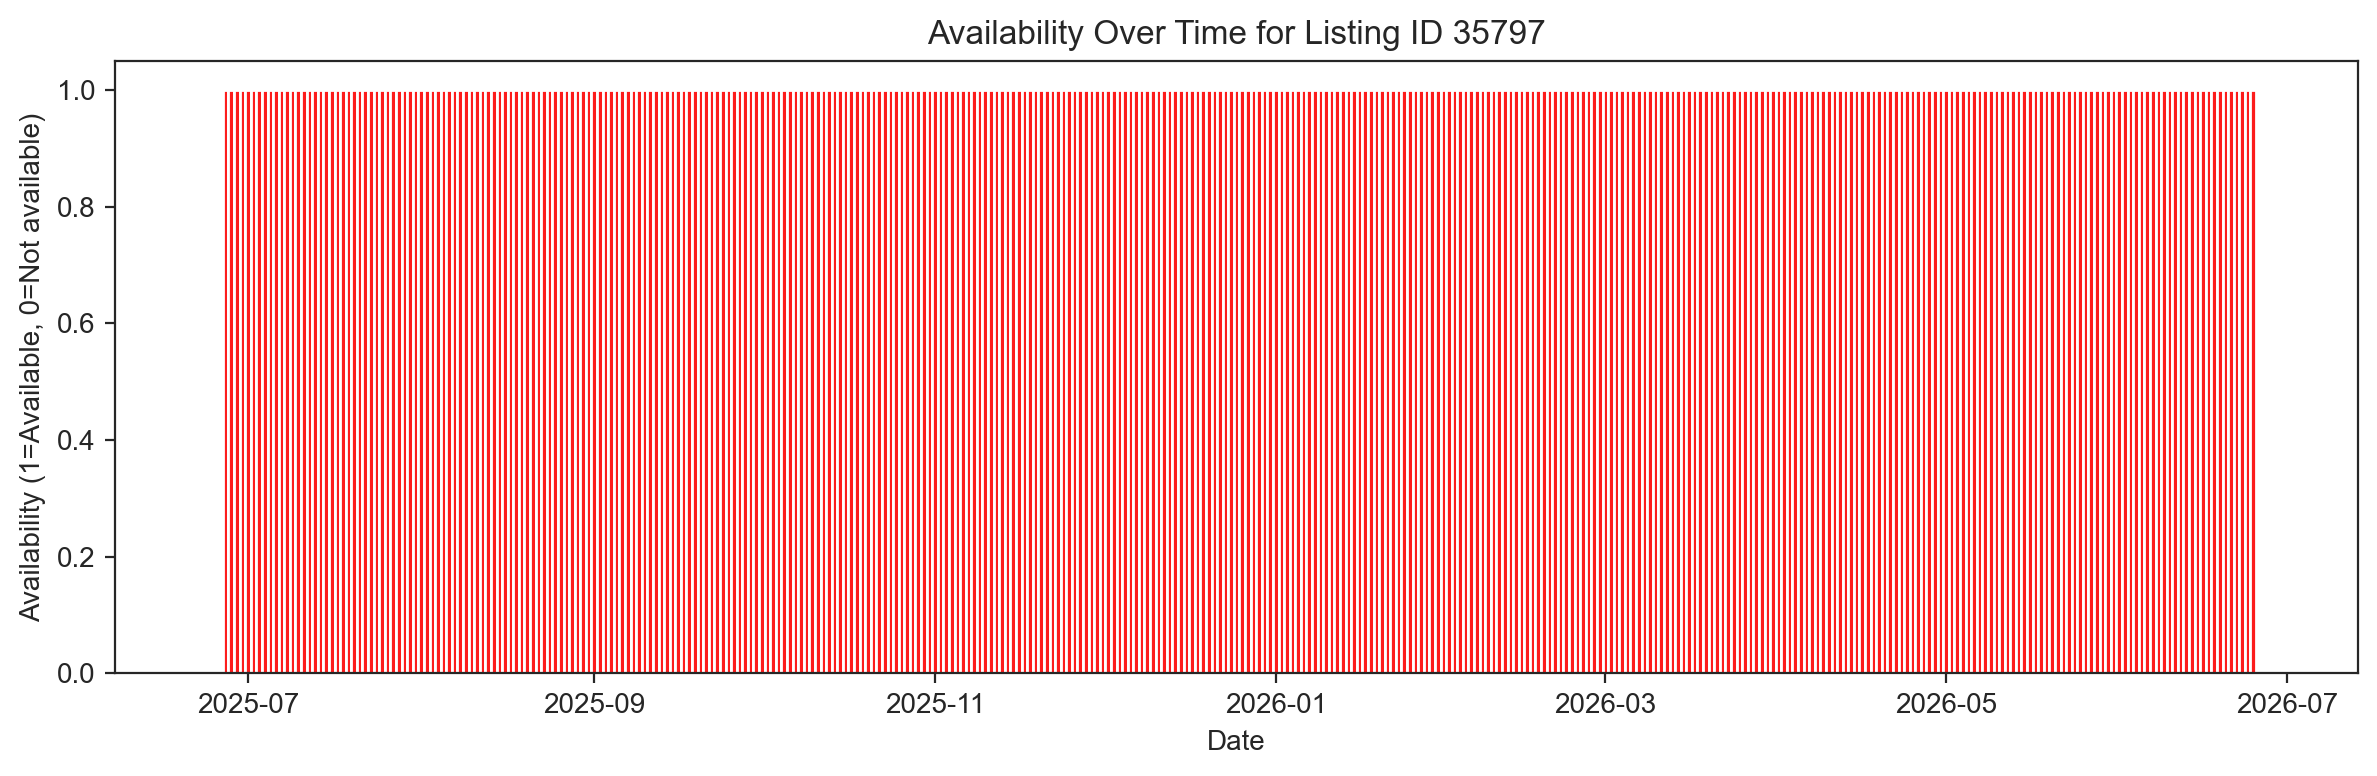

In [98]:
# grap the time series of availability for listing id 35797
listing_id = 35797
aux_calendar = calendar[calendar['listing_id'] == listing_id]
aux_calendar['available'] = aux_calendar['available'].map(lambda x: x == 't')
plt.figure(figsize=(12,4))
plt.bar(aux_calendar['date'], aux_calendar['available'].astype(int), color="#FC1C1C", width=1, align='center')
plt.ylabel('Availability (1=Available, 0=Not available)')
plt.xlabel('Date')
plt.title(f"Availability Over Time for Listing ID {listing_id}")
plt.tight_layout()
plt.show()

In [ ]:
def extract_pattern_availability(listing_id: int) -> str:
    """
    Extract the availability pattern for a given listing ID.
    """
    import sqlite3
    import pandas as pds
    import joblib

    # extract data from the database
    conn = sqlite3.connect('/Users/gblasd/Documents/SmartBnB/db/airbnb.db')
    query = f"""SELECT availability_rate, streaks, quarters_with_availability, max_consecutive_months_available
      FROM calendar_streaks WHERE id = {listing_id}"""
    listing_data = pd.read_sql_query(query, conn)
    conn.close()

    # Load the model
    kmeans = joblib.load('/models/kmeans_calendar_streaks.pkl')
    scaler = joblib.load('models/scaler_calendar_streaks.pkl')

    if listing_data.empty:
        #return "Listing ID not found."
        print("Listing ID not found.")

    # Prepare data for prediction
    features = [
        'availability_rate', 
        'streaks', 
        'quarters_with_availability', 
        'max_consecutive_months_available'
    ]
    X_listing = listing_data[features].fillna(0)
    X_scaled = scaler.transform(X_listing)

    # Predict cluster
    cluster_label = kmeans.predict(X_scaled)[0]

    # Map cluster label to name
    # Name of clusters based on availability patterns
    # Name of clusters based on availability patterns
    cluster_names = {
        0: 'Estacion Larga',
        1: 'Estacion Corta',
        2: 'Tiempo Parcial',
        3: 'Casi Disponible',
        4: 'Siempre Disponible',
        5: 'Evento Motivado',
        6: 'Bloqueado',
        7: 'Esporadico'
    }

    cluster_names_intuition = {
        0 : "Disponibilidad concentrada en temporadas largas.",
        1 : "Disponibilidad en temporadas cortas o específicas.",
        2 : "Disponibilidad parcial a lo largo del año.",
        3 : "Disponibilidad frecuente pero con algunas ausencias.",
        4 : "Disponibilidad casi completa durante todo el año.",
        5 : "Disponibilidad influenciada por eventos específicos.",
        6 : "Propiedad bloqueada o no disponible.",
        7 : "Disponibilidad esporádica sin un patrón claro."
    }

    cluster_name = cluster_names[cluster_label]
    intuition = cluster_names_intuition[cluster_label]

    # build json response
    response = {
        "listing_id": listing_id,
        # "cluster_label": int(cluster_label),
        "cluster_name": cluster_name,
        "intuition": intuition
    }

    return response

In [100]:
extract_pattern_availability(35797)

{'listing_id': 35797,
 'cluster_name': 'Siempre Disponible',
 'intuition': 'Disponibilidad casi completa durante todo el año.'}